# EDA의 목표
- 각 데이터셋의 분포화 특징을 살펴보고 심각도(타깃)의 영향을 줄 수 있는 컬럼을 알아본다.
- EDA 분석 진행을 하면서 결측치와 preprocessing을 함께 진행한다.
- Kaggle에서 제공된 Test의 경우 타깃값을 확인할 수 없기 때문에 Train으로 제공된 데이터만 사용한다.
- Test 데이터 생성을 위해 EDA이전 Split를 먼저하여 데이터 누수가 발생하지 않도록 한다.
- 포트폴리오용으로 split에서는 random_state를 사용한다.

In [1]:
# 필수 라이브러리
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정 (Windows - 맑은 고딕)
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [2]:
# 데이터 불러오기
accidents = pd.read_csv('./data/preprocessed/Accidents_train_preprocessed.csv')
places = pd.read_csv('./data/preprocessed/places_train_preprocessed.csv')
users = pd.read_csv('./data/preprocessed/users_train_preprocessed.csv')
vehicles = pd.read_csv('./data/preprocessed/vehicles_train_preprocessed.csv')

In [3]:
# Data split로 Test 데이터 생성하기
from sklearn.model_selection import train_test_split

# Gravity가 불균형(94.4% : 5.6%)하니 stratify로 비율 유지
accidents_train, accidents_test = train_test_split(
    accidents,
    test_size=0.2,
    stratify=accidents['Gravity'],
    random_state=19
)

train_ids = accidents_train['AccidentId']
test_ids = accidents_test['AccidentId']

# 2. 나머지 테이블들은 이 ID 기준으로 필터링
places_train = places[places['AccidentId'].isin(train_ids)]
places_test = places[places['AccidentId'].isin(test_ids)]

vehicles_train = vehicles[vehicles['AccidentId'].isin(train_ids)]
vehicles_test = vehicles[vehicles['AccidentId'].isin(test_ids)]

users_train = users[users['AccidentId'].isin(train_ids)]
users_test = users[users['AccidentId'].isin(test_ids)]

print(len(accidents_train), len(accidents_test))
print(len(places_train), len(places_test))
print(len(vehicles_train), len(vehicles_test))
print(len(users_train), len(users_test))

38257 9565
38257 9565
63500 15990
86992 21846


In [4]:
print("accidents_train:", accidents_train['AccidentId'].nunique())
print("places_train:", places_train['AccidentId'].nunique())
print("vehicles_train:", vehicles_train['AccidentId'].nunique())
print("users_train:", users_train['AccidentId'].nunique())

accidents_train: 38257
places_train: 38257
vehicles_train: 38257
users_train: 38257


## Accidents 데이터 셋

In [5]:
accidents_train.info()

<class 'pandas.DataFrame'>
Index: 38257 entries, 19444 to 5308
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   AccidentId        38257 non-null  int64  
 1   Gravity           38257 non-null  str    
 2   Date              38257 non-null  str    
 3   Hour              38257 non-null  str    
 4   Light             38257 non-null  str    
 5   Department        38257 non-null  int64  
 6   Commune           38257 non-null  int64  
 7   InAgglomeration   38257 non-null  str    
 8   IntersectionType  38257 non-null  str    
 9   Weather           38252 non-null  str    
 10  CollisionType     38256 non-null  str    
 11  PostalAddress     37892 non-null  str    
 12  GPSCode           38224 non-null  str    
 13  Latitude          37058 non-null  float64
 14  Longitude         37058 non-null  float64
dtypes: float64(2), int64(3), str(10)
memory usage: 4.7 MB


- 수치형 컬럼의 경우 사건의 고유 ID 값이나 위치정보를 숫자로 입력한 형태로 기초통계량은 확인하지 않는다.

### Gravity

In [6]:
# 타깃데이터 비율 확인하기
print(f'**Gravity counts**\n{accidents_train["Gravity"].value_counts()}\n')
print(f'**Gravity ratio**\n{accidents_train["Gravity"].value_counts(normalize=True) * 100}')

**Gravity counts**
Gravity
NonLethal    36128
Lethal        2129
Name: count, dtype: int64

**Gravity ratio**
Gravity
NonLethal    94.435005
Lethal        5.564995
Name: proportion, dtype: float64


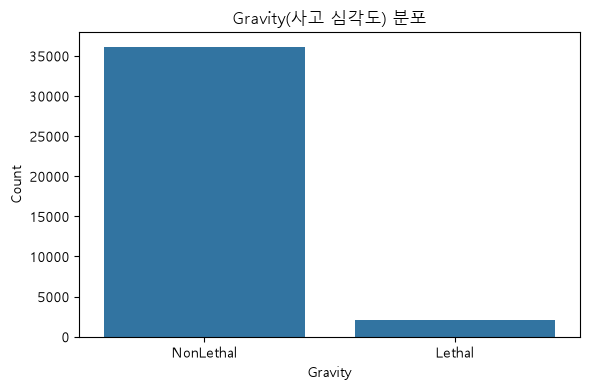

In [7]:
# 타깃데이터 Gravity 시각화
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=accidents_train, x='Gravity', order=accidents['Gravity'].value_counts().index)

# 막대 위에 건수 + 비율 같이 표시
total = len(accidents_train)
for p in ax.patches:
    count = p.get_height()
    pct = count / total * 100

plt.title('Gravity(사고 심각도) 분포')
plt.xlabel('Gravity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Date, Hour
- 2018년도 데이터이다.
- 월별, 요일별, 시간별로 사고 건수를 확인하고 타깃데이터와의 관계를 살펴본다.

In [8]:
# 파생변수 추출
accidents_train['Date'] = pd.to_datetime(accidents_train['Date'])
accidents_train['Month'] = accidents_train['Date'].dt.month
accidents_train['DayOfWeek'] = accidents_train['Date'].dt.day_name()
accidents_train['HourOfDay'] = accidents_train['Hour'].str.split(':').str[0].astype(int)

#### 월별기준으로 데이터 확인

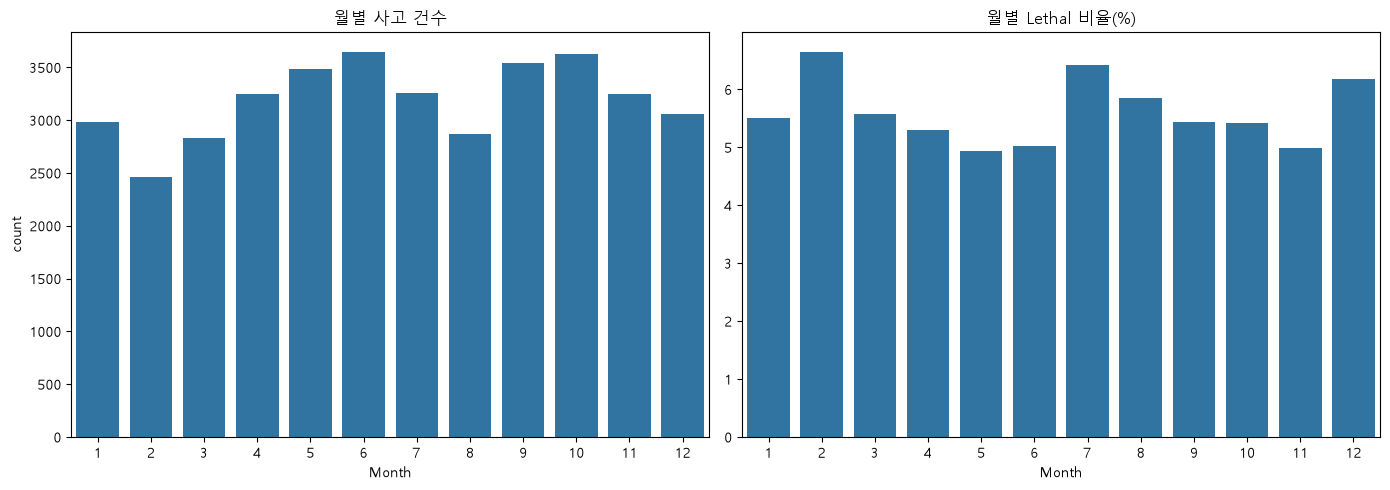

In [9]:
# 월별 사고 건수 + Lethal 비율

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 월별 건수 분포확인
sns.countplot(data=accidents_train, x='Month', ax=axes[0])
axes[0].set_title('월별 사고 건수')

# Lethal 비율
monthly_lethal_ratio = accidents_train.groupby('Month')['Gravity'].apply(lambda x: (x == 'Lethal').mean() * 100)
sns.barplot(x=monthly_lethal_ratio.index, y=monthly_lethal_ratio.values, ax=axes[1])
axes[1].set_title('월별 Lethal 비율(%)')

plt.tight_layout()
plt.show()

- 월별 사고건수는 2월이 제일 적었다는 수치를 확인할 수 있다. (28일로 일수가 적은 영향을 고려해볼 수 있다.)
- 월별 Lethal 비율은 약 5~6% 사이에서 분포하며, 사고 건수와 Lethal 비율의 패턴이 일치하지 않는다.
  - 예: 7월은 사고 건수는 중간 수준이지만 Lethal 비율이 가장 높음(~6.5%)
  - 5, 6, 10월은 사고 건수는 많지만 Lethal 비율은 상대적으로 낮음(~5%)
  - → 단순 사고 발생량과 별개로 월(계절)에 따라 사고의 위험도 자체가 달라질 가능성 시사

#### 요일별 기준으로 데이터 확인

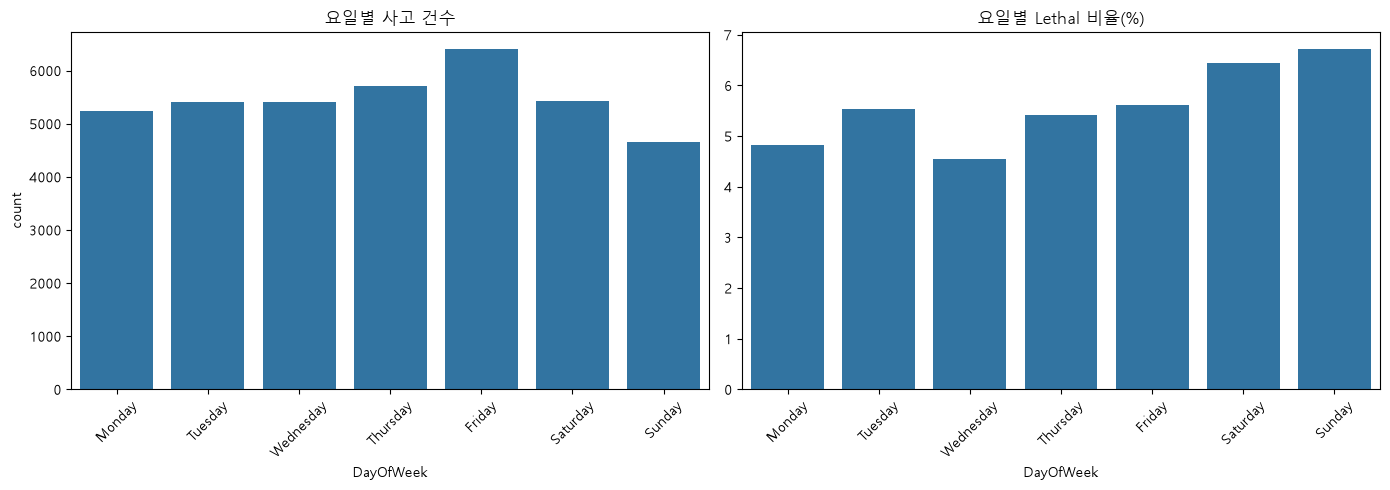

In [10]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 요일별 건수 확인
sns.countplot(data=accidents_train, x='DayOfWeek', order=day_order, ax=axes[0])
axes[0].set_title('요일별 사고 건수')
axes[0].tick_params(axis='x', rotation=45)

# 요일별 Lethal 비율
daily_lethal_ratio = accidents_train.groupby('DayOfWeek')['Gravity'].apply(lambda x: (x == 'Lethal').mean() * 100).reindex(day_order)
sns.barplot(x=daily_lethal_ratio.index, y=daily_lethal_ratio.values, ax=axes[1])
axes[1].set_title('요일별 Lethal 비율(%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- 요일별 사고 건수는 금요일이 제일 많았으며 주말은 오히려 전체적인 사고건수가 감소하는것을 보였다.
- 하지만 심각한 교통사고는 주말에는 6~7%대로 반대로 높았으며 평일에는 5% 대로 낮은것으로 확인된다.
- 이는 위의 정리와 같이 단순 사고 발생량과 별개로 요일에 따라 사고의 위험도가 달라질 수 있다는것을 시사한다.

#### 시간대 기준으로 데이터 확인

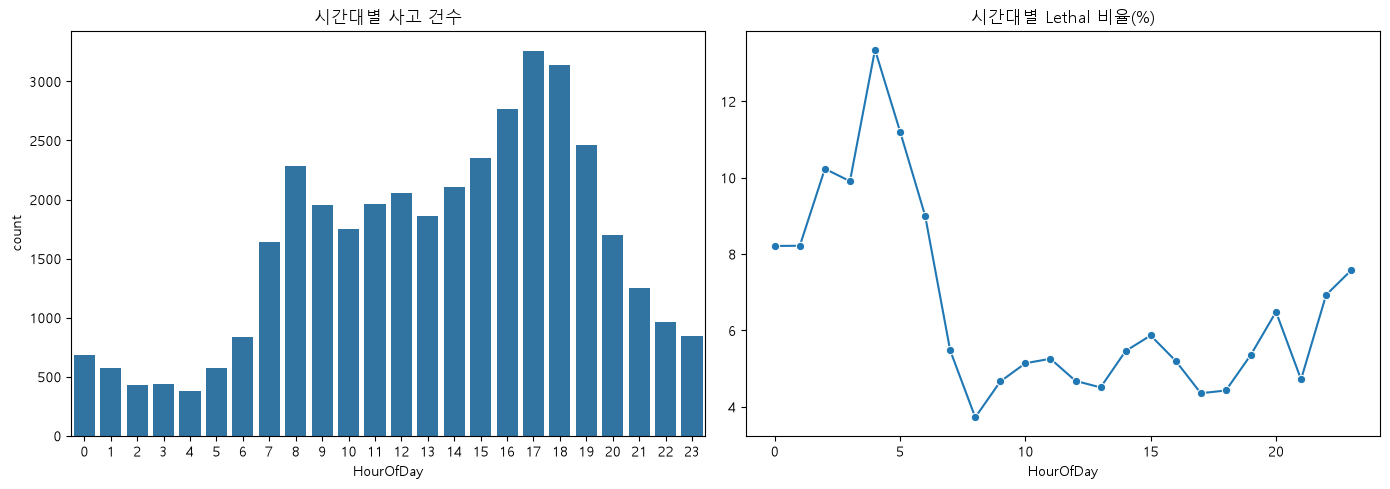

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=accidents_train, x='HourOfDay', ax=axes[0])
axes[0].set_title('시간대별 사고 건수')

hourly_lethal_ratio = accidents_train.groupby('HourOfDay')['Gravity'].apply(lambda x: (x == 'Lethal').mean() * 100)
sns.lineplot(x=hourly_lethal_ratio.index, y=hourly_lethal_ratio.values, ax=axes[1], marker='o')
axes[1].set_title('시간대별 Lethal 비율(%)')

plt.tight_layout()
plt.show()

- 교통사고 발생 건수는 퇴근시간대인 17-18시가 가장 높게 나타났다.
- 새벽 시간대는 통행량이 적은편으로 사고 발생 건수 자체도 낮은것을 알 수 있다.
- 하지만 Lethal 비율로 보면 정반대로 새벽시간대인 0-6시에 8-12%이상대로 다른 시간대보다 뚜렷하게 높게 나타났다.
- 다만 새벽4시의 뾰족한 피크는 해당 시간대 표본 수가 적어 통계적 변동성이 클 수 있으므로 특정 시각보다는 0-6시 구간이 전반적으로 높은 추세라고 해석하였다.

#### 결론 Date, Hour 결론
- Date, Hour 기존컬럼은 삭제처리하고 새로 생성한 월, 요일, 시간 컬럼을 사용한다.
- 핵심 인사이트인 주말과 새벽이 심각도가 높게 나온패턴을 이진 플래그로 추가한다.
- 주기성 인코딩의 경우 모델링 단계에서 고려하도록 한다.

In [12]:
# 이진 플래그 생성
accidents_train['IsWeekend'] = accidents_train['DayOfWeek'].isin(['Saturday', 'Sunday'])
accidents_train['IsNight'] = accidents_train['HourOfDay'].between(0, 6)

# 원본 컬럼 정리
accidents_train = accidents_train.drop(columns=['Date', 'Hour'])

In [13]:
# test 데이터에도 동일하게 적용

# 파생변수 추출
accidents_test['Date'] = pd.to_datetime(accidents_test['Date'])
accidents_test['Month'] = accidents_test['Date'].dt.month
accidents_test['DayOfWeek'] = accidents_test['Date'].dt.day_name()
accidents_test['HourOfDay'] = accidents_test['Hour'].str.split(':').str[0].astype(int)
# 이진 플래그 생성
accidents_test['IsWeekend'] = accidents_test['DayOfWeek'].isin(['Saturday', 'Sunday'])
accidents_test['IsNight'] = accidents_test['HourOfDay'].between(0, 6)
# 원본 컬럼 정리
accidents_test = accidents_test.drop(columns=['Date', 'Hour'])

### 범주형 컬럼

In [14]:
# 범주형 컬럼들의 시각화를 함수를 생성하여 사용
def plot_category_vs_gravity(col):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 왼쪽: 분포 (건수)
    sns.countplot(data=accidents_train, x=col, order=accidents[col].value_counts().index, ax=axes[0])
    axes[0].set_title(f'{col} 분포')
    axes[0].tick_params(axis='x', rotation=45)
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%d')

    # 오른쪽: Lethal 비율(%)
    lethal_ratio = accidents_train.groupby(col)['Gravity'].apply(lambda x: (x == 'Lethal').mean() * 100)
    lethal_ratio = lethal_ratio.sort_values(ascending=False)
    sns.barplot(x=lethal_ratio.index, y=lethal_ratio.values, ax=axes[1])
    axes[1].set_title(f'{col}별 Lethal 비율(%)')
    axes[1].tick_params(axis='x', rotation=45)
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt='%.1f%%')

    plt.tight_layout()
    plt.show()

#### Light 컬럼 데이터 확인 (조명상태)

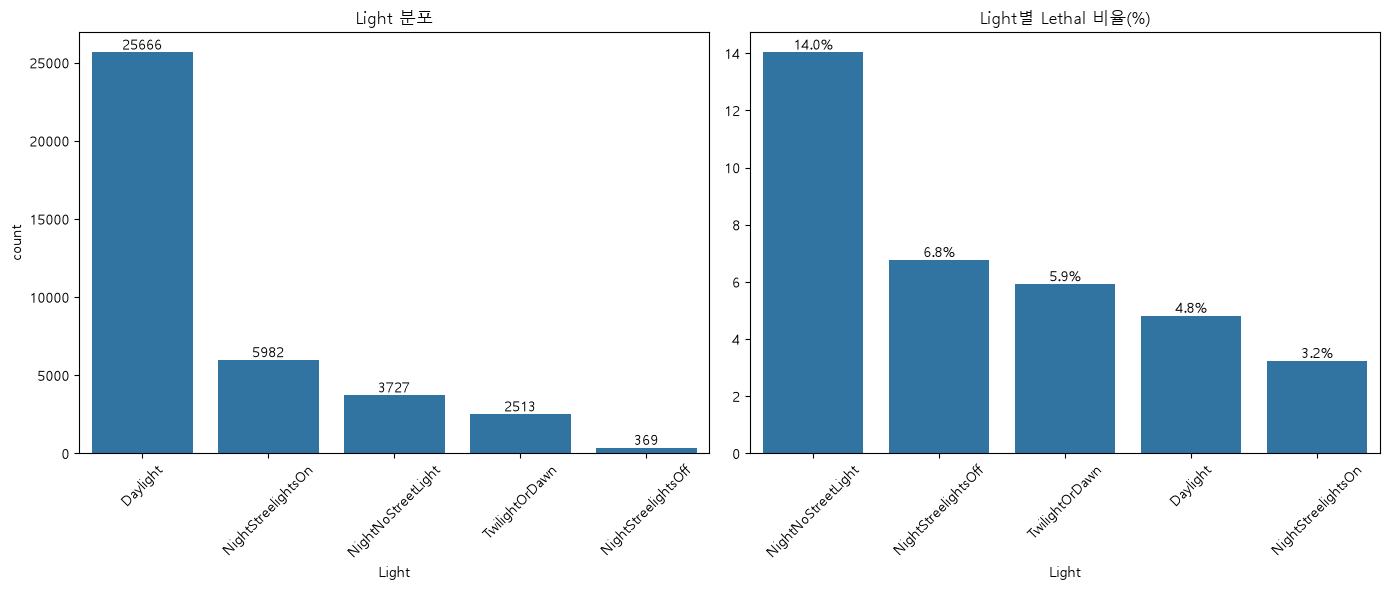

In [15]:
plot_category_vs_gravity('Light')

- Daylight는 일반적인 조명 상태로 교통사고 빈도에서도 압도적으로 높은 비중을 차지한다.
- 하지만 Lethal 비율로 확인시 정반대로 nightNoStreetLight가 14%으로 가장 높고 Daylight의 약 3배에 달한다.
- Lethal 비율 상위권의 라벨들은 모두 조명이 불충분한 상태인 반면 가로등이 켜진 야간은 오히려 최하위권으로 밤과 낮보다는 조명 부족이 위험 요인일 수 있다고 판단하였다.

#### InAgglomeration 컬럼 (도심 안에서 사고가 발생했는지에 대한 여부)

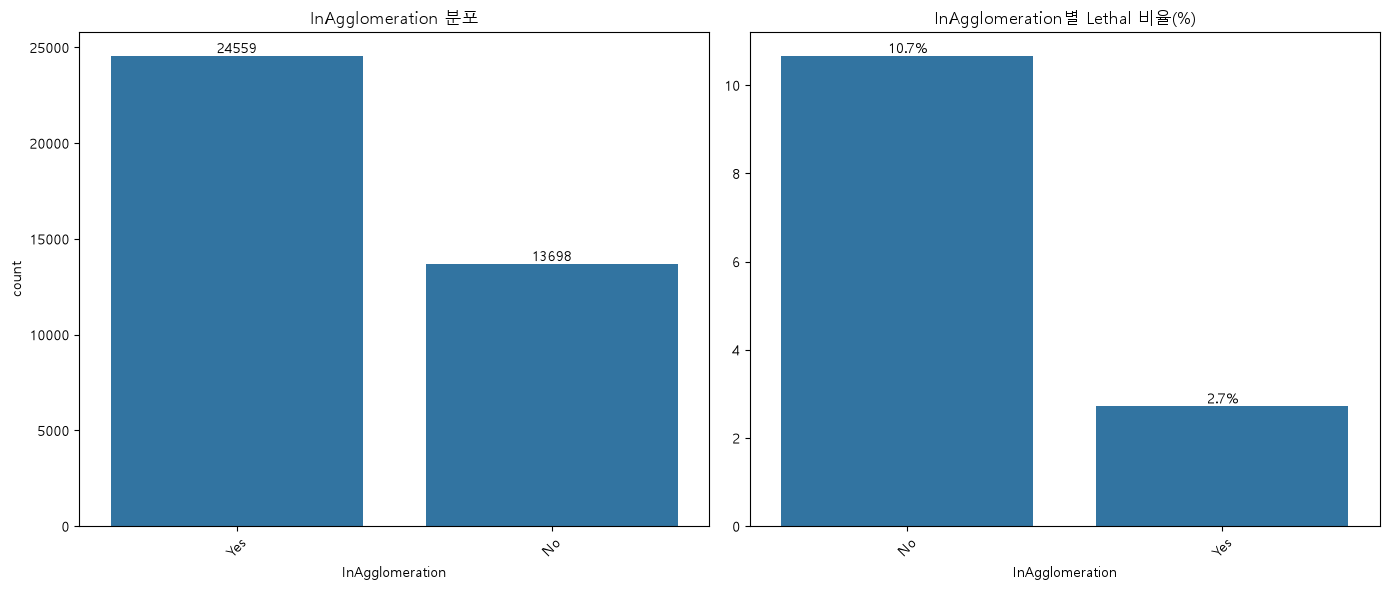

In [16]:
plot_category_vs_gravity('InAgglomeration')

- InAgglomeration을 확인시 도심내에서 사고의 빈도는 가장 높았다.
- 하지만 심각도 확인시 도심지역이 아닌곳이 10.7%, 도심에서는 2.7%대로 도심지역이 아닌곳에서 발생한 사고가 심각도가 높다는것을 알 수 있다.
- 또한 대체적으로 도심 밖이 고속도로같은 속도가 높은 도로 환경일 확률이 있어 도심지역보다 속도가 높은 환경일 가능성이 있다고 판단하였다.

#### IntersectionType 컬럼 분석 (교차로 유형)

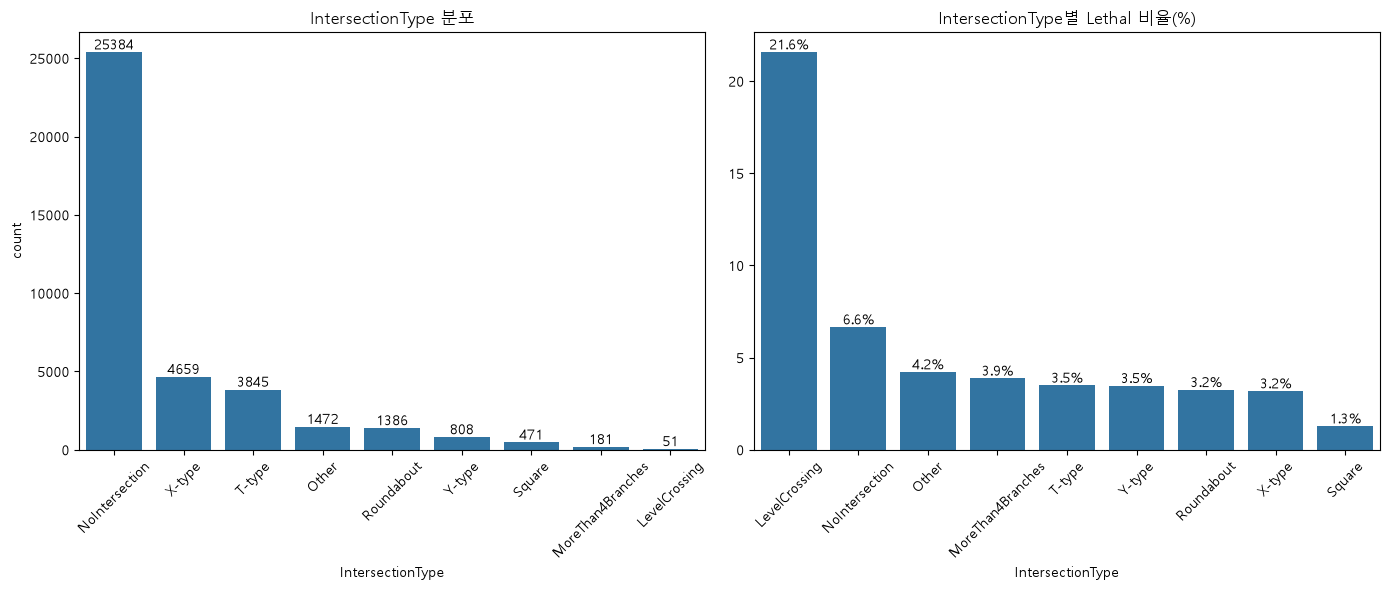

In [17]:
plot_category_vs_gravity('IntersectionType')

  - IntersectionType은 교차로가 아닌 일반도로(NoIntersection)에서 사고 빈도가 가장 많이 관측되었다(25384건).
  - Lethal 비율로 보면 철도건널목(LevelCrossing)이 21.6%로 가장 높았고, 사고 빈도가 가장 많았던 NoIntersection도 6.6%로 두 번째로 높은 비율을 보였다.
  - LevelCrossing은 철도와 차량 간 사고일 가능성이 있어 심각도가 높게 나타났을 것으로 추정되나, 반드시 철도 사고라 단정할 수는 없다.
  - 다만 LevelCrossing은 전체 표본이 51건으로 매우 적어, 소수의 심각한 사고만으로도 비율이 크게 튈 수 있다는 점을 감안해야 한다.
  - 반면 NoIntersection은 표본이 충분해(25384건) 6.6%라는 수치는 상대적으로 신뢰할 수 있다.
  - 차량 정보나 충돌 유형 등와 함께 보면 이 두 카테고리의 위험 요인을 더 명확히 구분할 수 있을 것으로 판단된다.

#### Weather 컬럼 분석 (날씨)

In [18]:
accidents_train['Weather'].isna().sum()

np.int64(5)

In [19]:
# train 결측치 'Unknown'으로 변경 (test에는 존재하지 않음)
accidents_train['Weather'] = accidents_train['Weather'].fillna('Unknown')

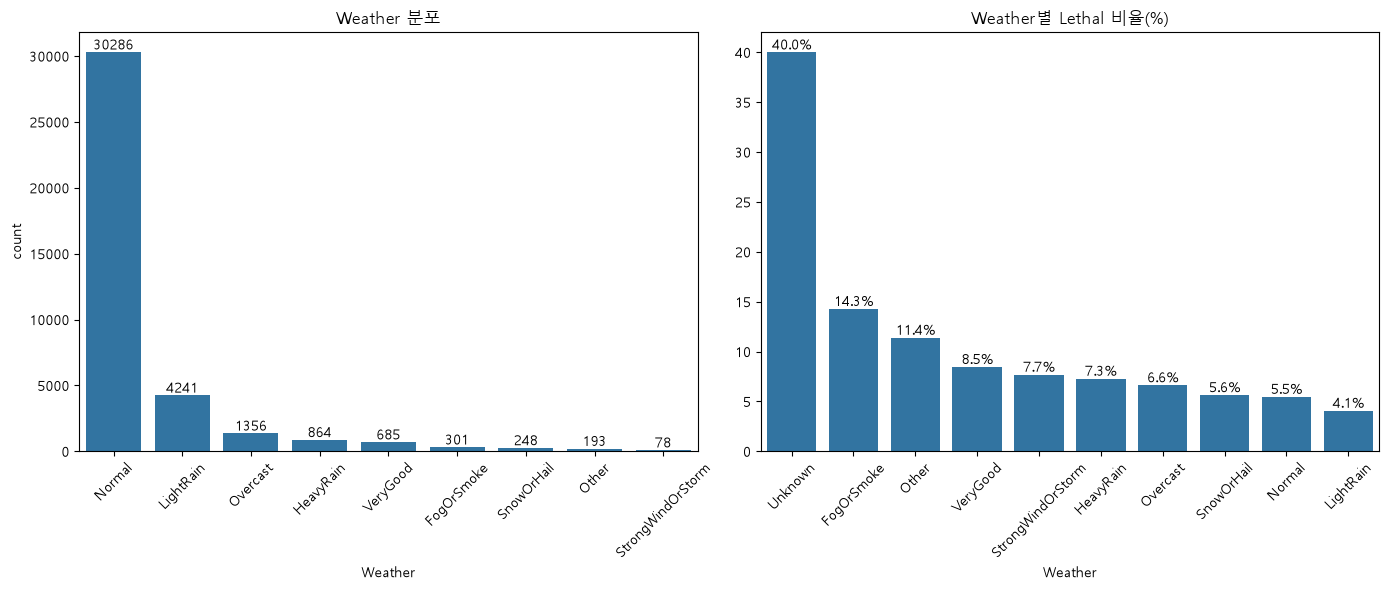

In [20]:
plot_category_vs_gravity('Weather')

- Weather는 대부분 Normal 상태에서 사고가 발생했으며 전체 사고의 절대다수를 차지했다.
- Normal, LightRain이 사고 빈도 1, 2위지만 Lethal 비율은 각각 5.5%, 4.1%로 오히려 가장 낮은 축에 속했다.
- Lethal 비율이 가장 높은 것은 FogOrSmoke(14.3%)였으나 이는 표본 자체가 301건으로 적어 소수의 심각한 사고에도 비율이 크게 나타났을 가능성이 있다.
- 다만 FogOrSmoke, Other, StrongWindOrStorm 등 시야 확보가 어렵거나 도로 상태가 불안정한 날씨일수록 Lethal 비율이 대체로 높게 나타나는 경향은 일관되게 확인된다.

#### CollisionType 컬럼 분석

In [21]:
accidents_train['CollisionType'].isna().sum()

np.int64(1)

- CollissionType의 결측치가 전체 데이터 중 1건으로 매우 적어 별도 대체 보다는 노이즈가 될 가능성을 고려하여 해당 행을 삭제처리한다.

In [22]:
accidents_train = accidents_train.dropna(subset=['CollisionType'])

In [23]:
# 삭제 확인
accidents_train['CollisionType'].isna().sum()

np.int64(0)

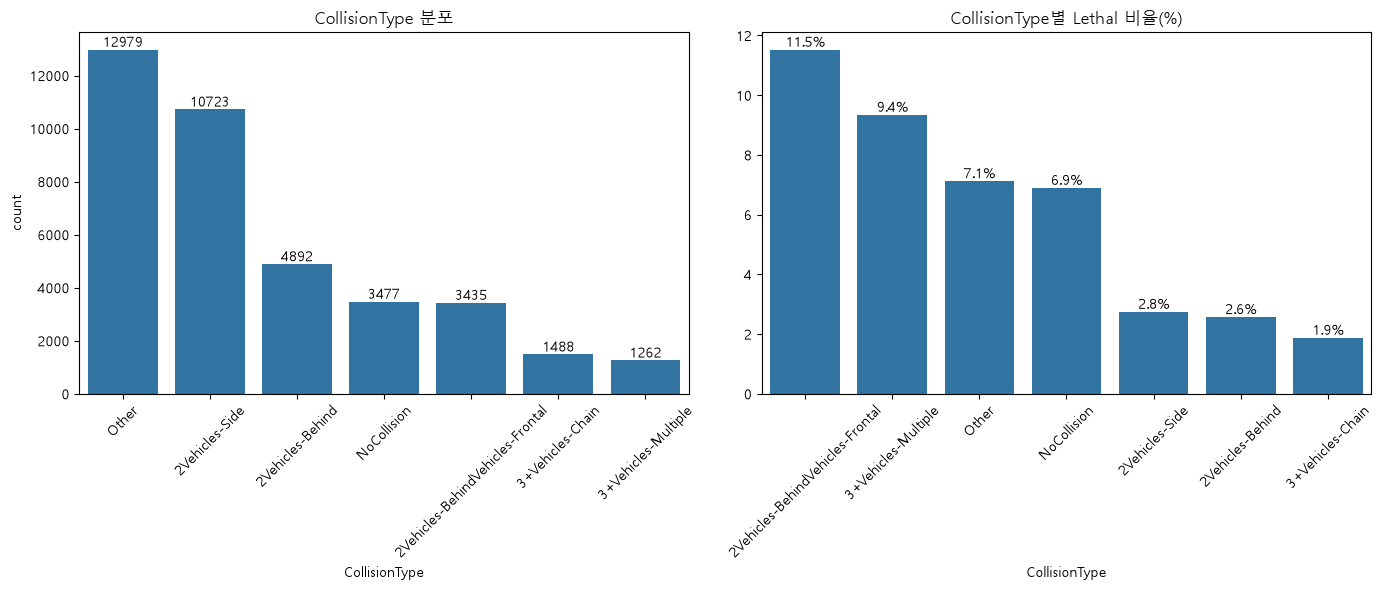

In [24]:
plot_category_vs_gravity('CollisionType')

- CollisionType 중 '2Vehicles-BehindVehicles-Frontal'(1488건)는 Lethal 비율이 11.5%로 전체 카테고리 중 가장 높게 나타났다.
- '2Vehicles-BehindVehicles-Frontal'라벨은 원본 데이터셋에 별도 메타데이터가 없어 정확한 정의를 확인할 수 없다.
- 다만 표본 수가 충분히 크고 Lethal 비율이 2Vehicles-Begind와 뚜렷한 차이를 보여 단순 오탈자나 중복이 아닌 별도의 위험도를 갖는 의도된 카테고리로 판단하였다.

#### Latitude, Longitude 컬럼 산점도로 위치정보 확인

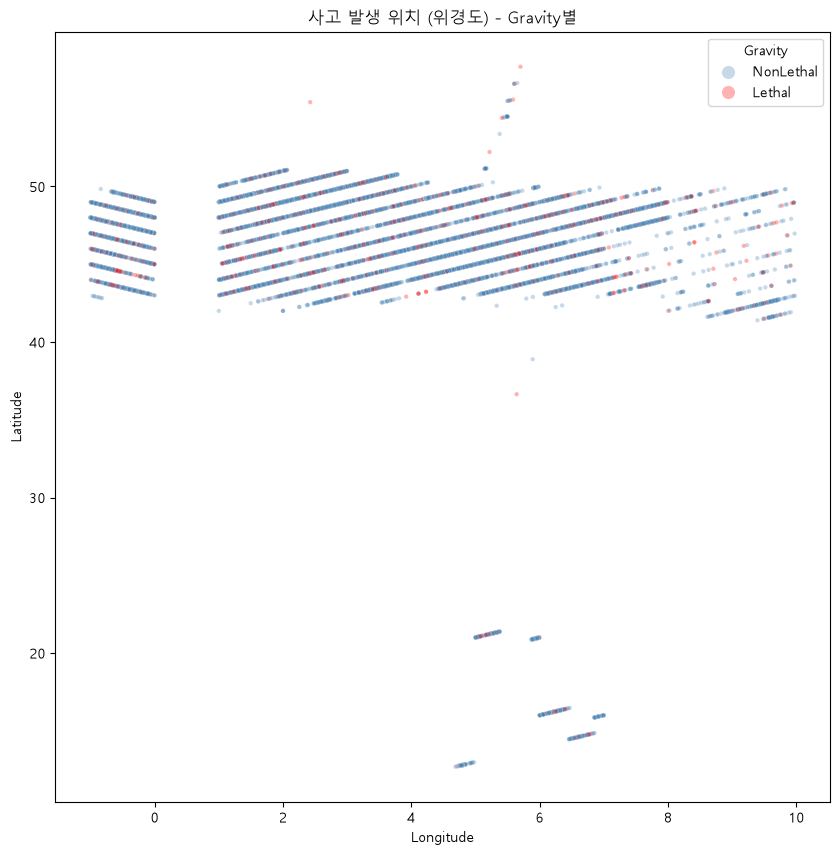

In [25]:
plt.figure(figsize=(10, 10))
sns.scatterplot(
    data=accidents_train,
    x='Longitude', y='Latitude',
    hue='Gravity',
    alpha=0.3,   # 점이 많이 겹치니 투명도로 밀도 표현
    s=10,         # 점 크기 작게
    palette={'NonLethal': 'steelblue', 'Lethal': 'red'}
)
plt.title('사고 발생 위치 (위경도) - Gravity별')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Gravity', markerscale=3)
plt.show()

- 산점도로 확인한 결과, 본토로 추정되는 영역에서도 자연스러운 분포가 아닌 일정한 격자형 줄무늬 패턴이 관찰되었다.
- 이는 좌표값이 정밀하게 측정되었다기보다 일정 단위로 근사/반올림되었을 가능성을 시사한다.
- 위경도의 정밀도와 신뢰도에 한계가 있다고 판단하여 해당 컬럼은 drop하기로 결정하였다.

#### 위치 관련 컬럼 처리 방향
- PostalAddress: 정해진 라벨이 없고 자유텍스트로 drop
- GPSCode: 단일값(M)에 근접하여 drop
- Latitude/Longitude: 수동입력 비중이 높고 신뢰도 이슈가 확인되어 drop
- Department/Commune: 행정구역 코드로, 숫자 인코딩 시 왜곡 위험이 있어 drop
- 이미 다른 컬럼(Light, Weather, InAgglomeration, IntersectionType 등)이 위험 요인을 충분히 설명하고 있어 위 컬럼들은 drop하기로 결정

In [26]:
drop_cols = ['PostalAddress', 'GPSCode', 'Latitude', 'Longitude', 'Department', 'Commune']

accidents_train = accidents_train.drop(columns=drop_cols)
accidents_test = accidents_test.drop(columns=drop_cols)

print(accidents_train.shape, accidents_test.shape)

(38256, 12) (9565, 12)


## Places 데이터 셋

In [27]:
# 데이터 요약 확인

summary = pd.DataFrame({
    'non_null': places_train.count(),
    'missing_pct': (places_train.isna().mean() * 100).round(1),
    'nunique': places_train.nunique()
})
print(summary.sort_values('missing_pct', ascending=False))

                    non_null  missing_pct  nunique
RoadSecNumber            109         99.7        2
RoadLetter              1782         95.3       36
StripWidth              8905         76.7       93
LaneWidth               9177         76.0      208
RoadNumber             23814         37.8     1497
RoadMarkerDistance     27646         27.7     1094
RoadMarkerId           27823         27.3      416
SurfaceCondition       34711          9.3       10
Layout                 34826          9.0        5
Infrastructure         34822          9.0        8
LaneNumber             37920          0.9       14
SpecialLane            37911          0.9        4
Localization           37932          0.8        6
Slope                  37960          0.8        5
SchoolNear             37951          0.8        3
Circulation            37984          0.7        5
RoadType               38257          0.0        8
AccidentId             38257          0.0    38257


#### 제외한 컬럼
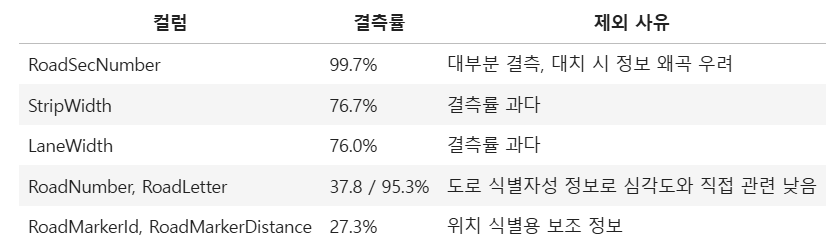
#### 심층 분석 대상
- RoadType, Circulation, LaneNumber, SpecialLane (도로 구조/통행방식)
- Slope, SurfaceCondition, Layout (도로 상태)
- Infrastructure, Localization, SchoolNear (주변 환경)

In [28]:
# 제외할 컬럼 Drop

drop_cols_places = [
    'RoadSecNumber',        # 결측률 99.7%
    'RoadLetter',           # 결측률 95.3%
    'StripWidth',           # 결측률 76.7%
    'LaneWidth',            # 결측률 76.0%
    'RoadNumber',           # 결측률 37.8%, 식별자성 정보
    'RoadMarkerDistance',   # 결측률 27.7%, 위치 식별용 보조 정보
    'RoadMarkerId',         # 결측률 27.3%, 위치 식별용 보조 정보
]

places_train = places_train.drop(columns=drop_cols_places)
places_test = places_test.drop(columns=drop_cols_places)

print(places_train.shape, places_test.shape)

(38257, 11) (9565, 11)


In [29]:
# 분석을 위해 Gravity 컬럼을 places_Train에 merge
places_train = places_train.merge(
    accidents_train[['AccidentId', 'Gravity']],
    on='AccidentId',
    how='left'
)

In [30]:
# 범주형 컬럼들의 시각화를 함수를 생성
def plot_category_vs_gravity(df, col):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 왼쪽: 분포 (건수)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=axes[0])
    axes[0].set_title(f'{col} 분포')
    axes[0].tick_params(axis='x', rotation=45)
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%d')

    # 오른쪽: Lethal 비율(%)
    lethal_ratio = df.groupby(col)['Gravity'].apply(lambda x: (x == 'Lethal').mean() * 100)
    lethal_ratio = lethal_ratio.sort_values(ascending=False)
    sns.barplot(x=lethal_ratio.index, y=lethal_ratio.values, ax=axes[1])
    axes[1].set_title(f'{col}별 Lethal 비율(%)')
    axes[1].tick_params(axis='x', rotation=45)
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt='%.1f%%')

    plt.tight_layout()
    plt.show()

#### RoadType 컬럼 분석 (사고가 발생한 도로 종류)

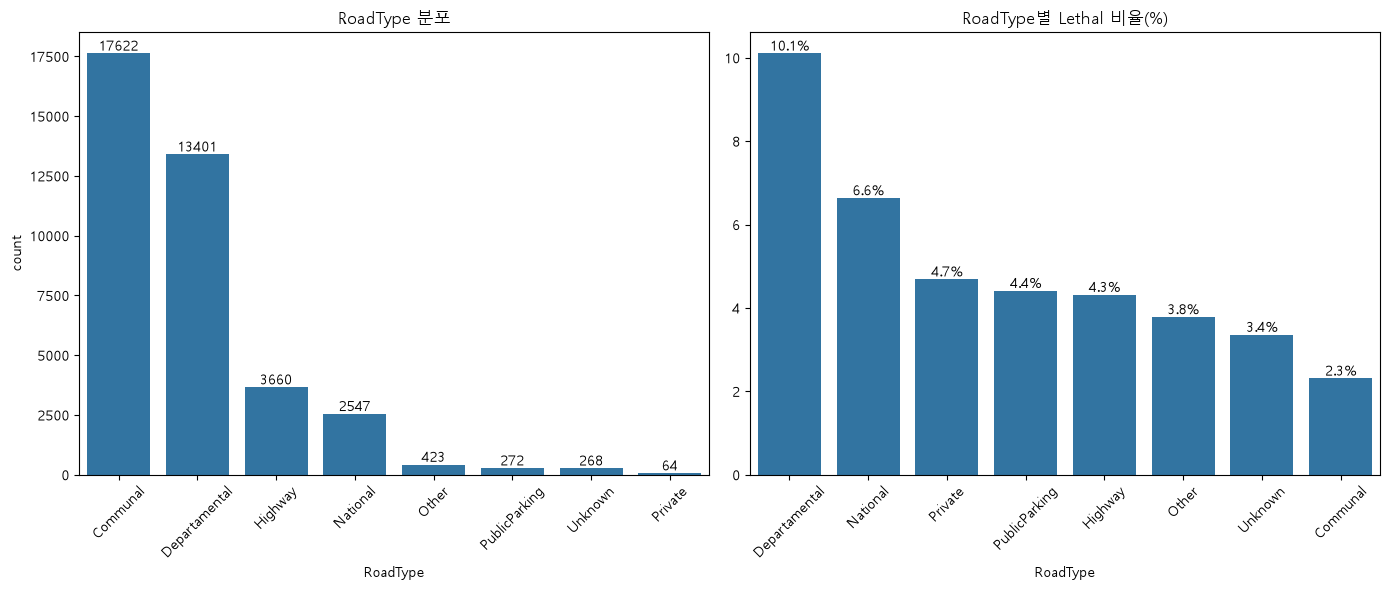

In [31]:
plot_category_vs_gravity(places_train,'RoadType')

- Communal은 사고 빈도는 가장 높지만 Lethal 비율은 가장 낮다. 이는 저속 주행 환경 특성으로 보인다.
- Departamental은 Lethal 비율이 10.1%로 가장 높다. 규정 속도는 있으나 고속도로 수준의 안전 설계는 부족한 도로 특성 때문으로 추정된다.
- Highway는 속도가 가장 높음에도 Lethal 비율이 Departamental보다 낮다. 통제된 진출입과 분리 차로 구조가 사고 심각도를 낮추는 것으로 보인다.
- 종합하면 규정 속도 자체보다 그에 걸맞은 도로 안전 설계 여부가 심각도에 더 크게 작용하는 것으로 판단된다.

#### Circulation 컬럼 분석 (도로의 통행 방식)

In [32]:
# 결측치 조회
places_train['Circulation'].isna().sum()

np.int64(273)

- Circulation 결측치 273건은 도로 유형이 존재하지만 기록되지 않았거나 구분이 불가능한 케이스로 판단된다.
- 이미 Unknown이라는 별도 카테고리가 존재하므로 새로운 라벨을 만들지 않고 기존 Unknown으로 통합하여 처리한다.

In [33]:
# 결측치 Unknown으로 처리하기
places_train['Circulation'] = places_train['Circulation'].fillna('Unknown')
places_test['Circulation'] = places_test['Circulation'].fillna('Unknown')

In [34]:
places_train['Circulation'].isna().sum()
places_test['Circulation'].isna().sum()

np.int64(0)

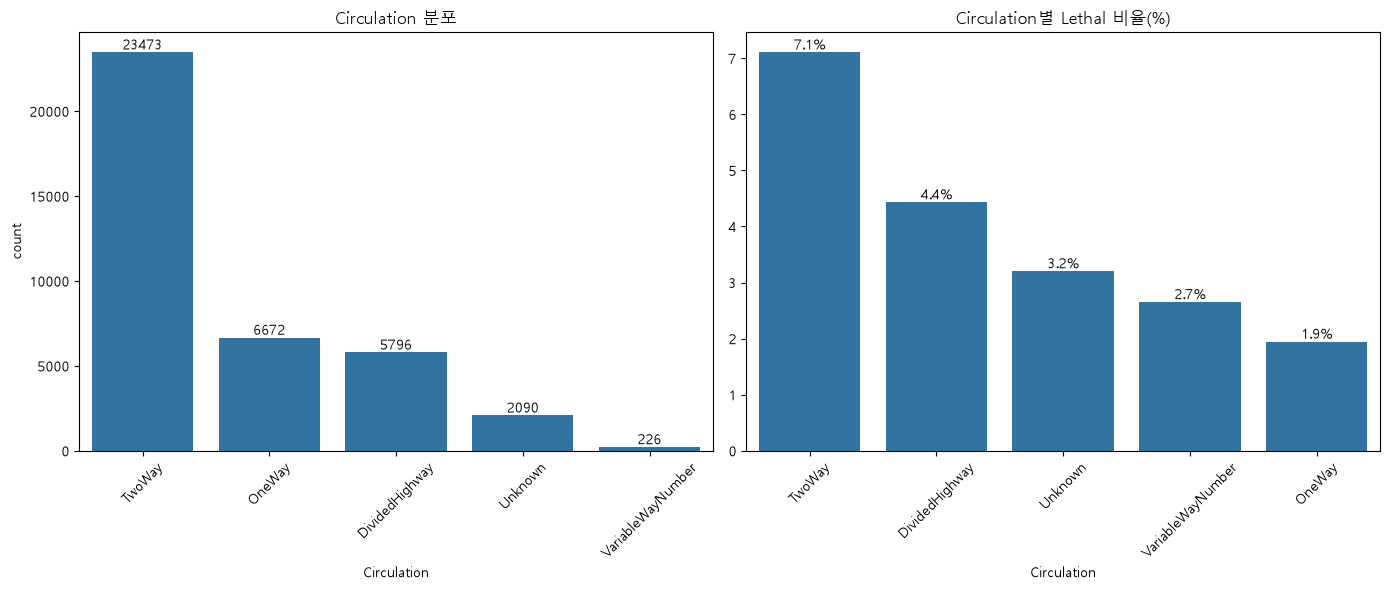

In [35]:
plot_category_vs_gravity(places_train,'Circulation')

- Circulation은 도로의 통행 방식으로 양방향, 일방통행, 분리도로 등을 나타낸다.
- TwoWay 양방향이며 중앙분리 없는 도로유형으로 Lethal 비율 7.1%로 가장 높다
- DividedHighway 중앙분리대 있는 양방향는 4.5%로 그보다 낮고 OneWay 일방통행는 1.9%로 가장 낮다.
- 이는 마주 오는 차량과의 정면충돌 가능성이 도로 구조에 따라 달라지기 때문으로 해석된다.

#### LaneNumber 컬럼 분석 (차선)

In [36]:
# 결측치 조회
places_train['LaneNumber'].isna().sum()

np.int64(337)

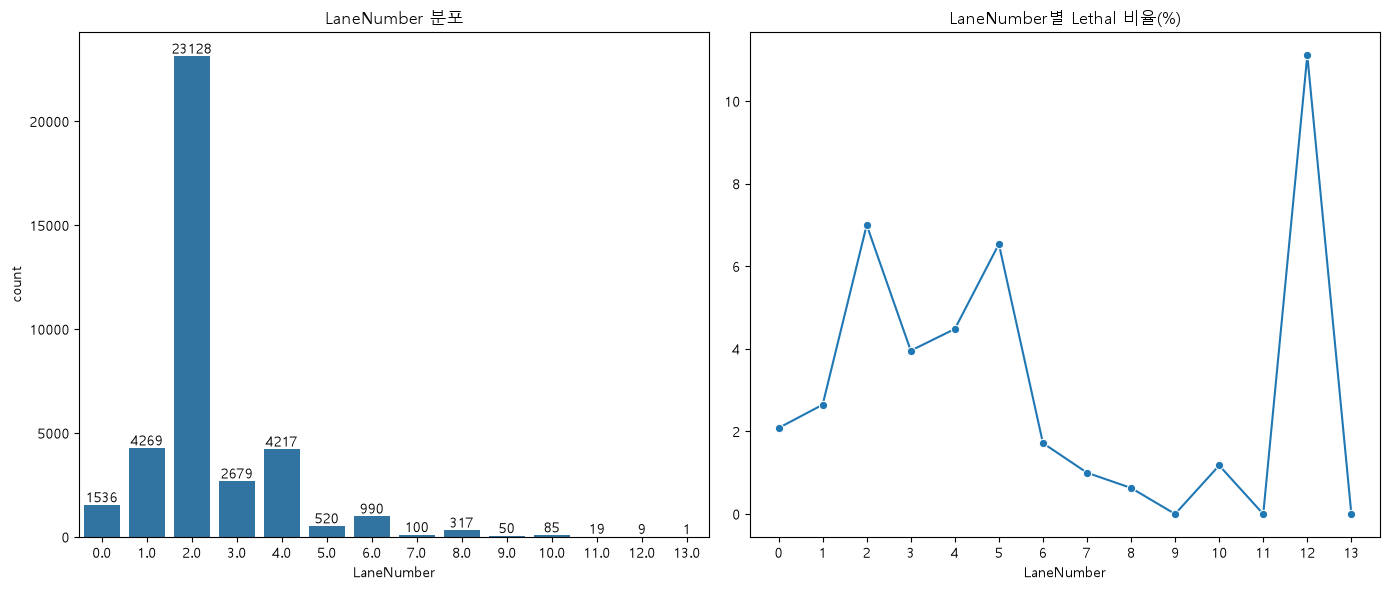

In [37]:
# LaneNumber 시각화

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽 분포 (건수)
lane_order = sorted(places_train['LaneNumber'].dropna().unique())
sns.countplot(data=places_train, x='LaneNumber', order=lane_order, ax=axes[0])
axes[0].set_title('LaneNumber 분포')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# 오른쪽 차선 수별 Lethal 비율
lethal_by_lane = places_train.groupby('LaneNumber')['Gravity'].apply(lambda x: (x == 'Lethal').mean() * 100)
sns.lineplot(x=lethal_by_lane.index, y=lethal_by_lane.values, marker='o', ax=axes[1])
axes[1].set_title('LaneNumber별 Lethal 비율(%)')
axes[1].set_xticks(lane_order)

plt.tight_layout()
plt.show()

- LaneNumber는 물리적으로 0차선이 존재할 수 없어 0.0 값은 차선 구분이 없거나 확인이 어려운 도로인 비포장로나 표시선 없는 소로 등을 나타내는 것으로 추정된다.
- 결측치 337건도 차선 수를 특정할 수 없는 동일한 상태로 판단하여 별도 카테고리를 만들지 않고 기존 0 값으로 통합한다.
- 또한 12차선의 경우 9건중 1건만 발생해도 10%로 뛰는 현상이 발생하며 13차선의 경우 1개의 차선으로 통계라고 하기 어려운 부분이 있다.
- 7차선부터는 100건으로 급감하는 부분으로 7차선부터 13차선까지 7+ 범주로 묶고, 숫자로 표기된 범주형 변수로 변환한다. 

In [38]:
# 결측치를 0으로 대치 (차선 구분 불가로 판단)
places_train['LaneNumber'] = places_train['LaneNumber'].fillna(0)
places_test['LaneNumber'] = places_test['LaneNumber'].fillna(0)

In [39]:
#  7차선 이상을 '7+' 그룹으로 통합, 범주형으로 변환
def bucket_lane(n):
    if n >= 7:
        return '7+'
    else:
        return str(int(n))

places_train['LaneNumber'] = places_train['LaneNumber'].apply(bucket_lane)
places_test['LaneNumber'] = places_test['LaneNumber'].apply(bucket_lane)

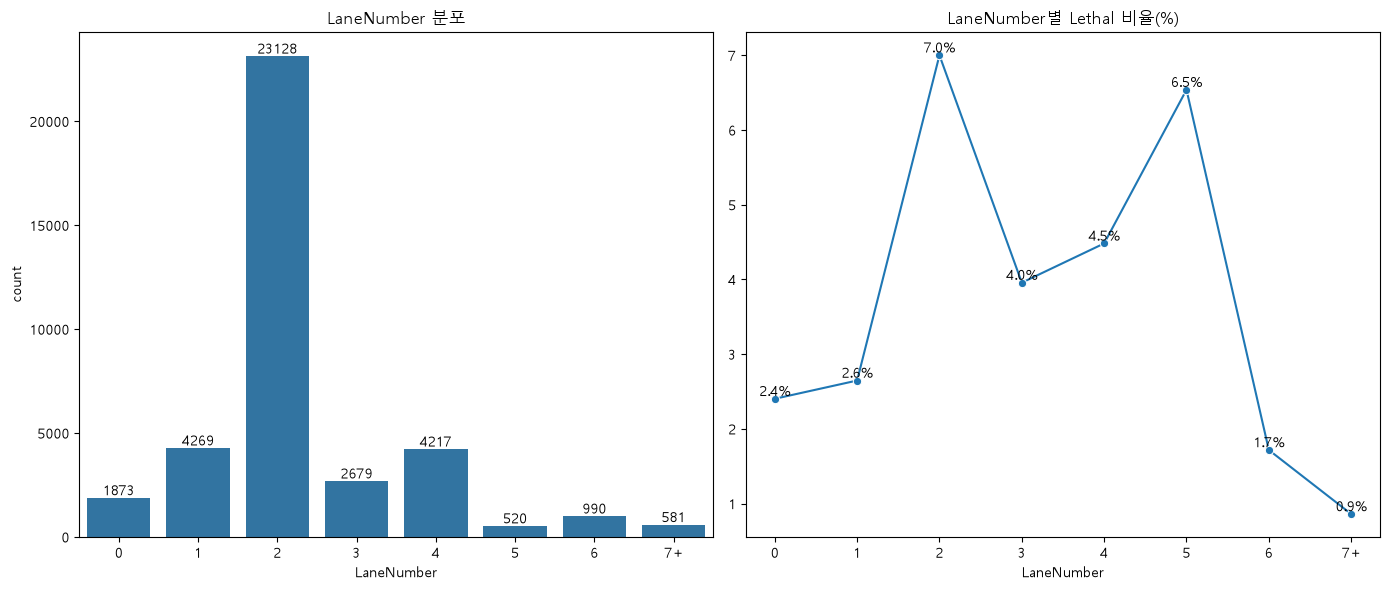

In [40]:
# 변경된 라벨 시각화
lane_order = ['0', '1', '2', '3', '4', '5', '6', '7+']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 왼쪽: 분포 (건수)
sns.countplot(data=places_train, x='LaneNumber', order=lane_order, ax=axes[0])
axes[0].set_title('LaneNumber 분포')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# 오른쪽: 차선 수별 Lethal 비율 추세 (line plot)
lethal_ratio = places_train.groupby('LaneNumber')['Gravity'].apply(lambda x: (x == 'Lethal').mean() * 100).reindex(lane_order)
sns.lineplot(x=lethal_ratio.index, y=lethal_ratio.values, marker='o', ax=axes[1])
axes[1].set_title('LaneNumber별 Lethal 비율(%)')
for x, y in zip(lethal_ratio.index, lethal_ratio.values):
    axes[1].annotate(f'{y:.1f}%', (x, y), ha='center', va='bottom')

plt.tight_layout()
plt.show()

- LaneNumber별 Lethal 비율은 뚜렷한 단조 증가/감소 추세 없이 구간별로 등락을 보인다.
- 7+ 구간은 통합후에도 0.9% 가장 낮게 나타나며 이는 다차선 도로가 앞서 확인한 Highway처럼 통제된 진출입과 분리 차로 구조를 갖춰 오히려 안전할 가능성을 시사한다.
- 다만 2차선, 5차선이 유독 높은 이유는 차선 수 자체보다 해당 차선 수를 가진 도로 유형이나 통행 방식 과 결합해서 봐야 더 명확히 해석할 수 있을것으로 판단된다.

#### SpecialLane 컬럼 분석

In [41]:
places_train['SpecialLane'].isna().sum()

np.int64(346)

In [42]:
# SpecialLane이 결측인 행들
missing_special = places_train[places_train['SpecialLane'].isna()]

print('SpecialLane 결측 건수:', len(missing_special))
print()

# 이 행들의 Circulation 분포
print('결측 행의 Circulation 분포:')
print(missing_special['Circulation'].value_counts(normalize=True) * 100)
print()

# 이 행들의 LaneNumber 분포
print('결측 행의 LaneNumber 분포:')
print(missing_special['LaneNumber'].value_counts(normalize=True) * 100)

SpecialLane 결측 건수: 346

결측 행의 Circulation 분포:
Circulation
Unknown           73.988439
TwoWay            21.965318
OneWay             2.601156
DividedHighway     1.445087
Name: proportion, dtype: float64

결측 행의 LaneNumber 분포:
LaneNumber
0     74.855491
2     19.942197
1      3.179191
4      1.445087
7+     0.289017
5      0.289017
Name: proportion, dtype: float64


- SpecialLane 결측치는 같은 행의 Circulation, LaneNumber 분포를 확인해 본 결과 약 74%가 `Circulation=Unknown, LaneNumber=0`과 겹치는것으로 확인된다.
- 이는 도로 정보를 명확히 특정하기 어려운 도로에서 여러 컬럼이 동시에 결측/미상 처리되는 공통 패턴으로 볼 수있다고 판단하였다.
- SpecialLane 결측치도 '특수차선없음(0)'으로 채우는 것이 기존 패턴과 일관되며 타당하다고 판단하여 `0`으로 대치하였다.

In [43]:
# 결측치 0값으로 대치
places_train['SpecialLane'] = places_train['SpecialLane'].fillna('0')
places_test['SpecialLane'] = places_test['SpecialLane'].fillna('0')

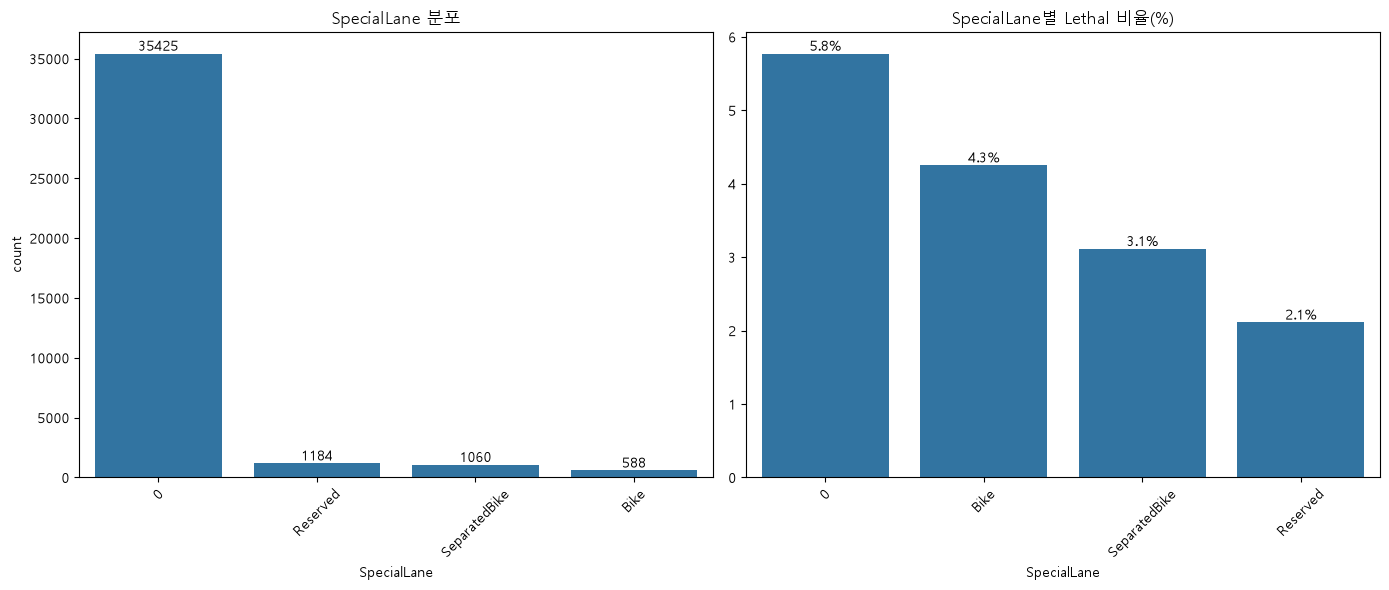

In [44]:
# 분포 시각화 확인
plot_category_vs_gravity(places_train,'SpecialLane')

#### Slope 컬럼 분석 (도로의 경사로)

In [45]:
places_train['Slope'].isna().sum()

np.int64(297)

In [46]:
# 결측치 Unknown값으로 대치
places_train['Slope'] = places_train['Slope'].fillna('Unknown')
places_test['Slope'] = places_test['Slope'].fillna('Unknown')

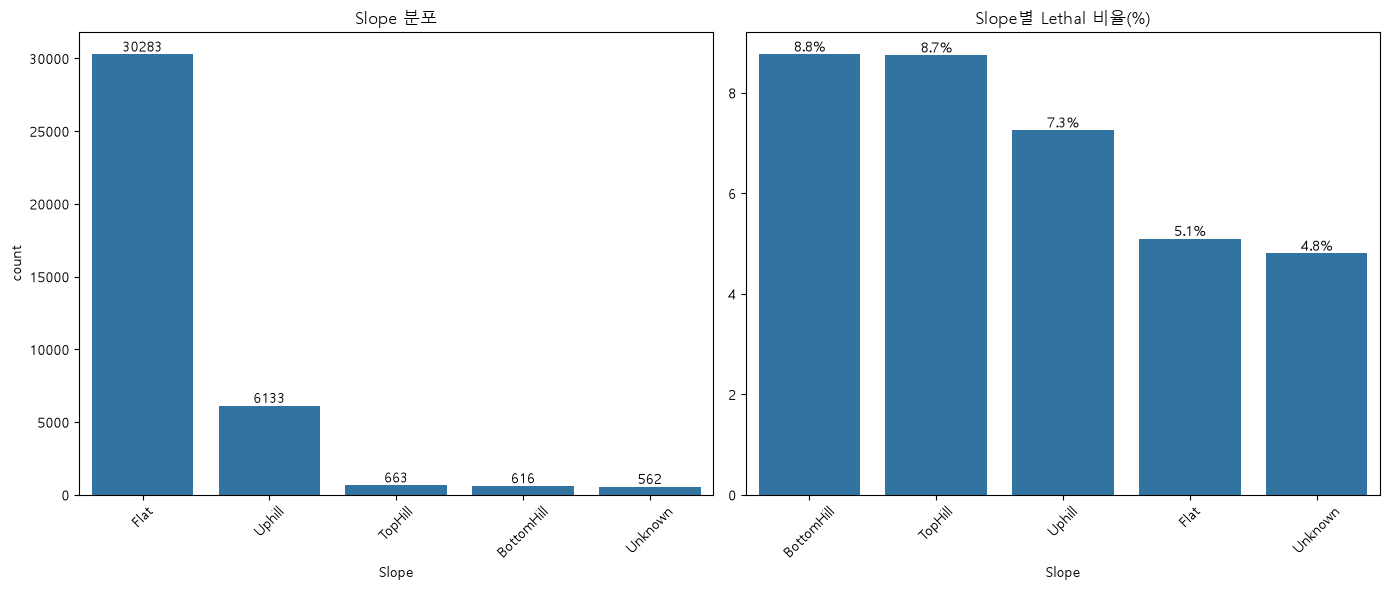

In [47]:
# 분포 시각화 확인
plot_category_vs_gravity(places_train,'Slope')

- Slope 결측치는 SpecialLane처럼 특정 값으로 대체할 논리적 근거가 없어 별도 카테고리를 만들지 않고 기존의 범주인 'Unknown'으로 처리하였다.
- 결측 비율이 전체 대비 작은 수준이라 별도 범주로 묶어도 노이즈 영향은 제한적일 것으로 판단하였다.
- 결측 수정 후 분포를 확인시 Falt는 전반적으로 경사로가 있는 범주보다 낮은 Lethal로 확인되었다.

####  Layout 컬럼 분석 (도로 모양 Curve)

In [48]:
places_train['Layout'].isna().sum()

np.int64(3431)

In [49]:
# 결측치 Missing값으로 대치
places_train['Layout'] = places_train['Layout'].fillna('Missing')
places_test['Layout'] = places_test['Layout'].fillna('Missing')

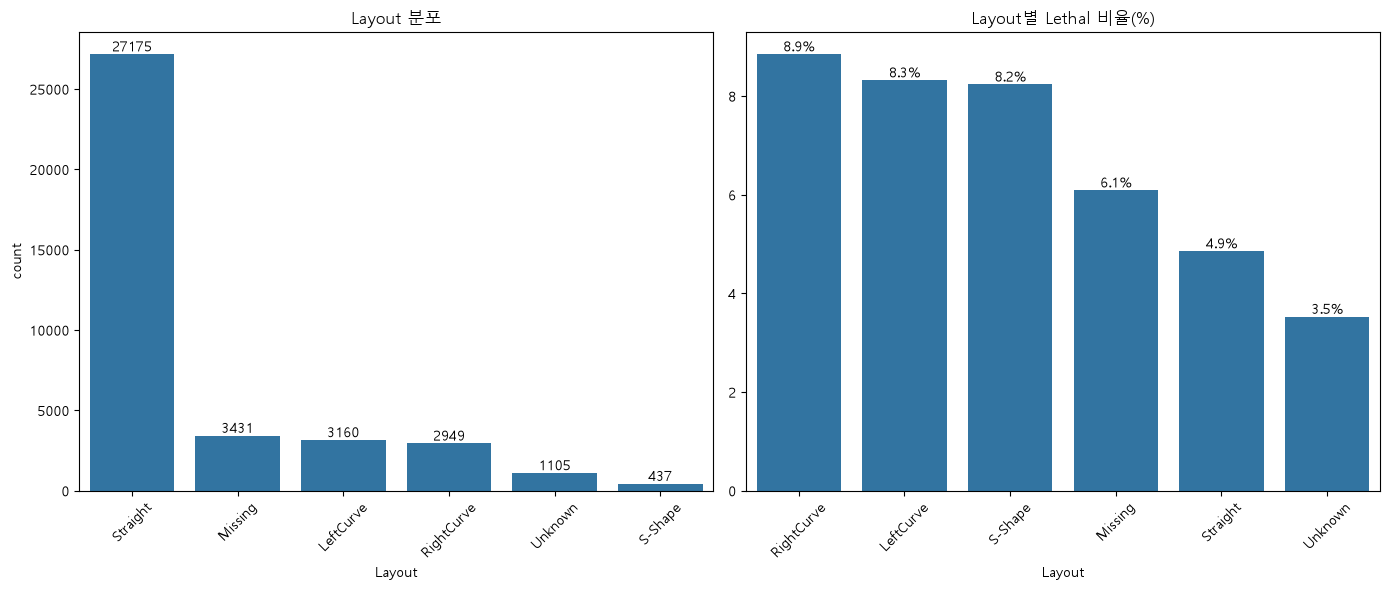

In [50]:
# 분포 시각화
plot_category_vs_gravity(places_train,'Layout')

- Layout의 결측치는 3231건으로 확인된다.
- 이 수치의 경우 Unknown으로 합치기보다는 알 수 없는 값이 아닌 값 자체가 누락된 케이스로 Missing 라벨로 대치한다.
- 또한 분포표를 확인해보면 커브길인 경우 약8%대로 평지보다 Lethal이 높게 나오는 패턴을 확인할 수 있었다.

#### SurfaceCondition 컬럼 분석 (도로 표면 상태)

In [51]:
places_train['SurfaceCondition'].isna().sum()

np.int64(3546)

In [52]:
# 결측치 Missing값으로 대치
places_train['SurfaceCondition'] = places_train['SurfaceCondition'].fillna('Missing')
places_test['SurfaceCondition'] = places_test['SurfaceCondition'].fillna('Missing')

- Layout의 결측치는 3231건으로 확인된다.
- 이 수치의 경우 Unknown으로 합치기보다는 알 수 없는 값이 아닌 값 자체가 누락된 케이스로 Missing 라벨로 대치한다.

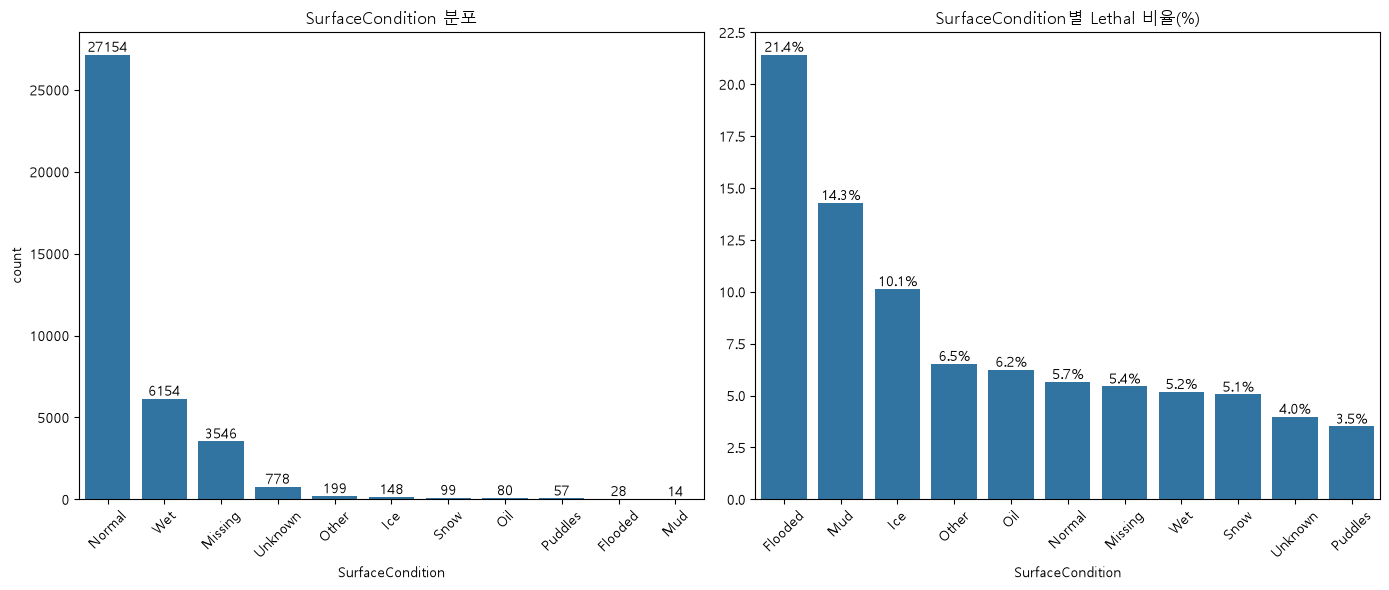

In [53]:
# 분포 시각화
plot_category_vs_gravity(places_train,'SurfaceCondition')

- 현재 라벨들이 표본이 적어 Lethal 비율이 높게 나오는것이 확인됨
- 도메인적으로 비슷한 라벨끼리 묶어 전후를 비교하여 채택하는것으로 판단하였다.

In [54]:
# 도메인별로 묶기

def bucket_surface(val):
    if val in ['Ice', 'Oil', 'Flooded', 'Mud']:
        return 'Dangerous'
    elif val in ['Wet', 'Snow', 'Puddles']:
        return 'Affected'
    elif val == 'Normal':
        return 'Normal'
    elif val == 'Missing':
        return 'Missing'
    elif val in ['Unknown']:
        return 'Unknown'
    else:  
        return 'Other'

places_train['SurfaceCondition_new'] = places_train['SurfaceCondition'].apply(bucket_surface)

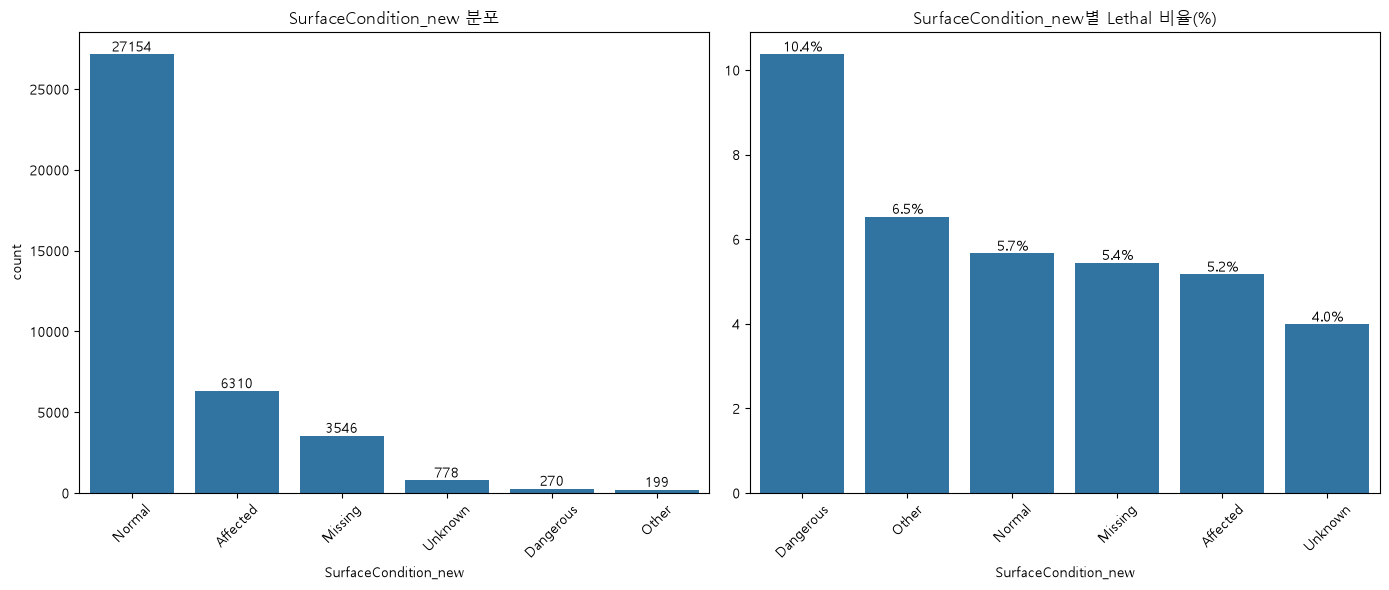

In [55]:
# 분포 시각화
plot_category_vs_gravity(places_train,'SurfaceCondition_new')

- 원본 라벨의 의미와 도로 표면 상태를 고려하여 도메인 관점에서 라벨을 재분류하였다.
- 빙판, 미끄러운 노면, 침수, 진흙 등 차량 운행에 직접적인 위험을 초래할 수 있는 도로 상태를 Dangerous로 분류하였다.
- 젖은 노면, 눈, 물웅덩이 등 정상적인 도로 상태와는 다르지만 상대적으로 위험도가 낮은 상태를 Affected로 분류하였다.
- Normal, Unknown, Other는 기존 의미를 유지하였으며 결측값은 Missing으로 별도 분류하였다.
- 재분류 결과 Dangerous는 270건 중 Lethal 비율이 10.4%로 가장 높게 나타났다. 이는 다른 범주에 비해 치명적인 사고의 비율이 상대적으로 높은 것으로 확인되지만 빈도가 270건으로 낮은편이다.
- 반면 Affected의 Lethal 비율은 5.2%로 Normal의 5.7%보다 낮게 나타나 예상과 달리 노면 상태가 일부 영향을 받은 경우가 반드시 높은 사고 심각도로 이어지는 것은 아닌 것으로 확인되었다.
- 또한 Missing의 Lethal 비율은 5.4%로 Unknown의 4.0%보다 높게 나타났다. 이에 따라 결측값과 Unknown은 서로 다른 의미를 가질 수 있다고 판단하여 두 범주를 별도로 유지하였다.

In [56]:
# 변경된 라벨 적용하기
places_train['SurfaceCondition'] = places_train['SurfaceCondition'].apply(bucket_surface)
places_test['SurfaceCondition'] = places_test['SurfaceCondition'].apply(bucket_surface)

In [57]:
#SurfaceCondition_new 컬럼 삭제
places_train = places_train.drop(columns=['SurfaceCondition_new'])

#### Infrastructure 컬럼 분석 (도로·교통 인프라 특성)

In [58]:
places_train['Infrastructure'].isna().sum()

np.int64(3435)

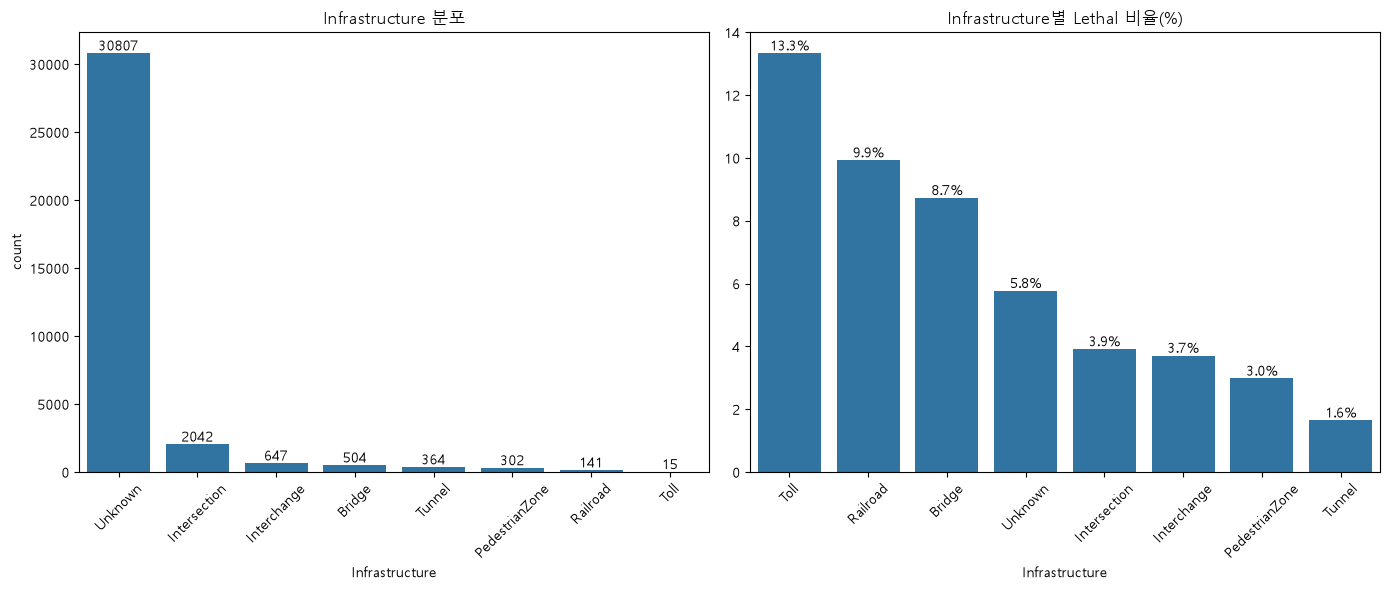

In [59]:
# 분포 시각화
plot_category_vs_gravity(places_train,'Infrastructure')

- Infrastructure 컬럼은 기존 번주가 의미가 명확하고 각 인프라 유형을 나타내므로 원본 라벨을 유지하였다.
- 다만 결측치는 Unknown과 의미가 다를 수 있고 3,435건으로 충분한 규모를 차지하므로 Missing 라벨로 별도 분류하였다.

In [60]:
# 결측치 Missing값으로 대치
places_train['Infrastructure'] = places_train['Infrastructure'].fillna('Missing')
places_test['Infrastructure'] = places_test['Infrastructure'].fillna('Missing')

#### Localization 컬럼 분석 (사고 발생 도로의 유형)

In [61]:
places_train['Localization'].isna().sum()

np.int64(325)

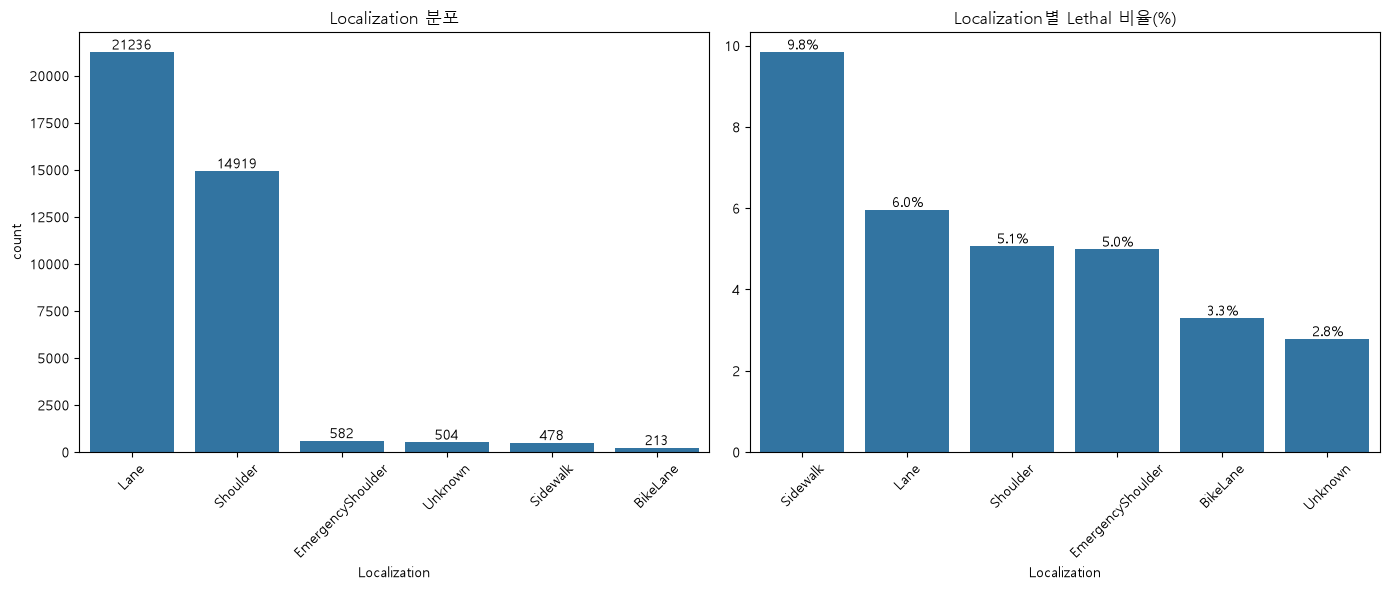

In [62]:
# 분포 시각화
plot_category_vs_gravity(places_train,'Localization')

- 결측치의 경우 사고 위치를 알 수 없는 Unknown으로 합치는것이 적절하다고 판단했다.
- 결측치도 결국 사고 위치를 알수없는 정보이며 325건으로 많은 건수가 아니기 때문에 Unknown으로 대치한다.

In [63]:
# 결측치 Missing값으로 대치
places_train['Localization'] = places_train['Localization'].fillna('Unknown')
places_test['Localization'] = places_test['Localization'].fillna('Unknown')

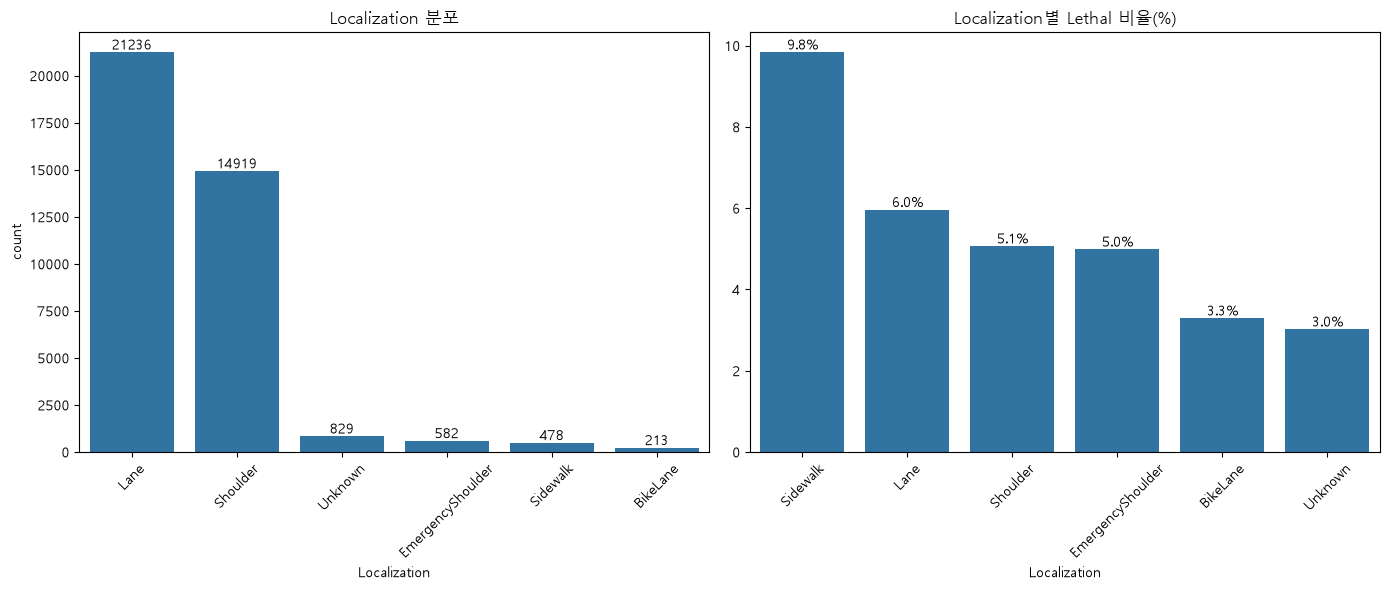

In [64]:
# 결측치 대치 후 시각화
plot_category_vs_gravity(places_train,'Localization')

#### SchoolNear 컬럼 분석 (학교 주변 여부)

In [65]:
places_train['SchoolNear'].isna().sum()

np.int64(306)

- SchoolNear는 사고 발생 지점의 학교 근접 여부를 나타내는 변수이다.
- 라벨의 의미를 찾기 위해 Kaggle 데이터를 조사하여 Khiops의 2018년도 교통사고 데이터라는 정보를 얻을 수 있었다.
- 이 라벨들은 범주형 변수로 0 = 학교 근접 여부 미기재, 3 = 학교 근처, 99 = 학교 근처 아님이라는 정보를 얻었다.
- 결측치의 경우 값의 기록이 없기 때문에 미기재인 0과 같은 라벨로 분류한다.
- 또한 라벨의 의미를 명확하게 하기 위해 라벨명을 수정하여 분포를 확인한다.

In [66]:
# 라벨 재정의

def bucket_school(val):
    if val == 3:
        return 'Yes'
    elif val == 99:
        return 'No'
    else:
        return 'Missing'

places_train['SchoolNear'] = places_train['SchoolNear'].apply(bucket_school)
places_test['SchoolNear'] = places_test['SchoolNear'].apply(bucket_school)

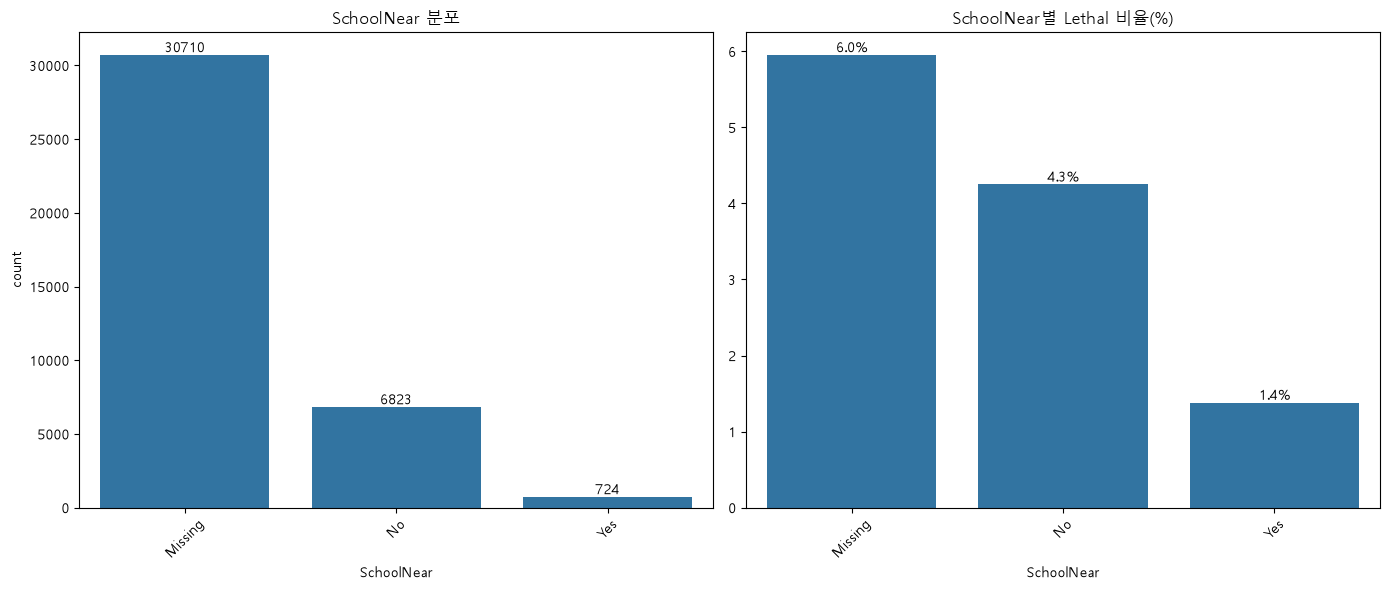

In [67]:
# 분포 시각화
plot_category_vs_gravity(places_train,'SchoolNear')

## users 데이터 셋
- 사고의 인적정보를 담고있는 데이터 셋

In [68]:
users_train.isna().sum()

AccidentId                0
VehicleId                 0
Seat                   8406
Category                  0
Gender                 1205
TripReason            19894
SafetyDevice           3934
SafetyDeviceUsed      10413
PedestrianLocation    80373
PedestrianAction      80228
PedestrianCompany     37086
BirthYear              2996
dtype: int64

In [69]:
# drop할 컬럼
# VehicleId,TripReason

In [70]:
# 분석을 위해 Gravity 컬럼을 places_Train에 merge
users_train = users_train.merge(
    accidents_train[['AccidentId', 'Gravity']],
    on='AccidentId',
    how='left'
)

### Category 컬럼 분석 (차량정보)

In [71]:
users_train['Category'].unique()

<StringArray>
[             'Car<=3.5T',       'Motorbike>125cm3',                'Bicycle',
          'Scooter<50cm3',   'Scooter_50cm3-125cm3',                'Utility',
  'LargeCar+Trailer>3.5T',                'Tractor',                  'Moped',
     'LargeCar_3.5T-7.5T', 'Motorbike_50cm3-125cm3',         'Scooter>125cm3',
            'Quadricycle',      'Truck+SemiTrailer',                  'Coach',
          'LargeCar>7.5T',         'QuadBike>50cm3',                    'Bus',
          'SpecialEngine',                  'Other',                  'Truck',
        'QuadBike<=50cm3',                  'Train',                'Tramway']
Length: 24, dtype: str

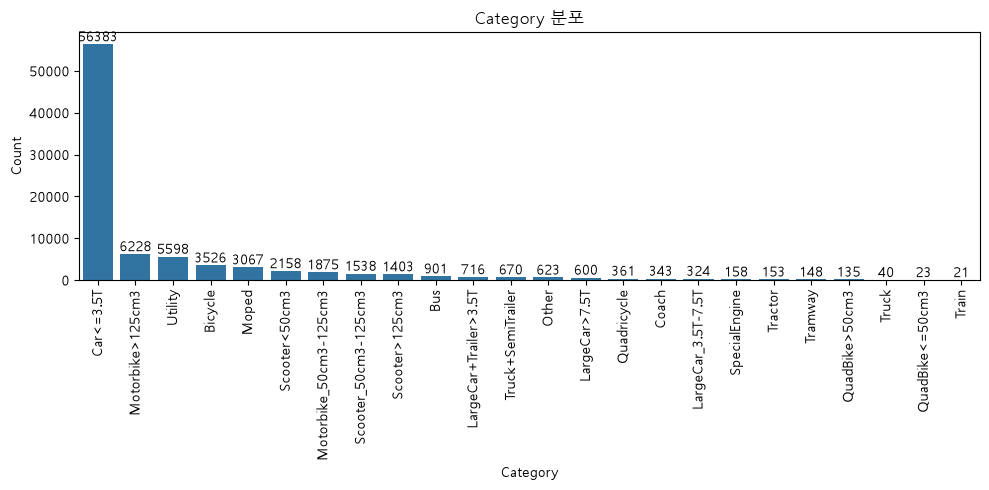

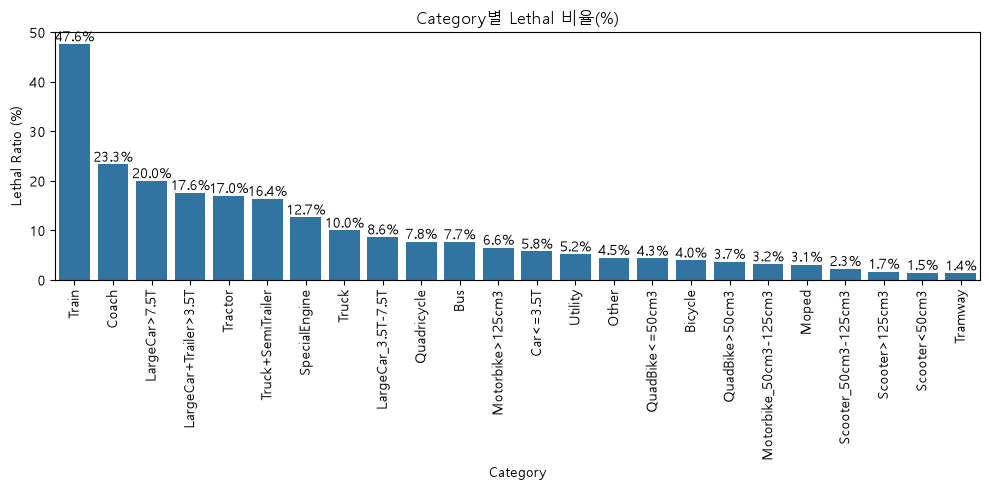

In [72]:
# Category 분포 - 건수
plt.figure(figsize=(10, 5))

category_order = users_train['Category'].value_counts().index

ax = sns.countplot(data=users_train, x='Category', order=category_order)
ax.set_title('Category 분포')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=90)

for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()


# Category별 Lethal 비율
plt.figure(figsize=(10, 5))

lethal_ratio = (
    users_train.groupby('Category')['Gravity']
    .apply(lambda x: (x == 'Lethal').mean() * 100)
    .sort_values(ascending=False))

ax = sns.barplot(x=lethal_ratio.index, y=lethal_ratio.values)
ax.set_title('Category별 Lethal 비율(%)')
ax.set_xlabel('Category')
ax.set_ylabel('Lethal Ratio (%)')
ax.tick_params(axis='x', rotation=90)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

- 표본 수가 적은 세부 차량 유형의 안정적인 학습을 위해 유사한 특성을 가진 차량 유형을 그룹화하여 라벨을 재정의함

In [73]:
category_mapping = {
    # PassengerCar
    'Car<=3.5T': 'PassengerCar',

    # TwoWheeler
    'Motorbike>125cm3': 'TwoWheeler',
    'Motorbike_50cm3-125cm3': 'TwoWheeler',
    'Scooter<50cm3': 'TwoWheeler',
    'Scooter_50cm3-125cm3': 'TwoWheeler',
    'Scooter>125cm3': 'TwoWheeler',
    'Moped': 'TwoWheeler',

    # Bicycle
    'Bicycle': 'Bicycle',

    # HeavyVehicle
    'Utility': 'HeavyVehicle',
    'LargeCar+Trailer>3.5T': 'HeavyVehicle',
    'LargeCar_3.5T-7.5T': 'HeavyVehicle',
    'LargeCar>7.5T': 'HeavyVehicle',
    'Truck+SemiTrailer': 'HeavyVehicle',
    'Truck': 'HeavyVehicle',

    # PublicTransport
    'Bus': 'PublicTransport',
    'Coach': 'PublicTransport',

    # SpecialVehicle
    'Tractor': 'SpecialVehicle',
    'SpecialEngine': 'SpecialVehicle',
    'Train': 'SpecialVehicle',

    # FourWheelMotorcycle
    'Quadricycle': 'FourWheelMotorcycle',
    'QuadBike>50cm3': 'FourWheelMotorcycle',
    'QuadBike<=50cm3': 'FourWheelMotorcycle',

    # Tramway
    'Tramway': 'Tramway',

    # Other
    'Other': 'Other'
}

users_train['Category'] = users_train['Category'].replace(category_mapping)
users_test['Category'] = users_test['Category'].replace(category_mapping)

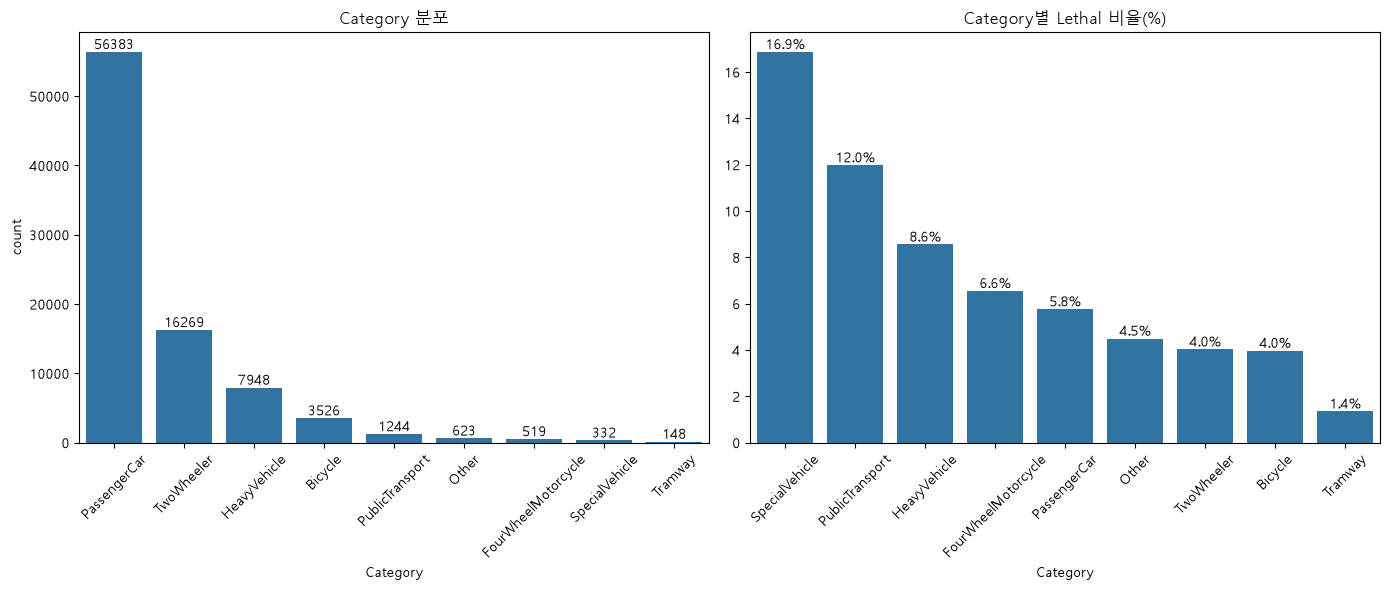

In [74]:
# 시각화
plot_category_vs_gravity(users_train, 'Category')

#### Seat 컬럼 분석 (차량 좌석 정보)

In [75]:
users_train['Seat'].isna().sum()

np.int64(8406)

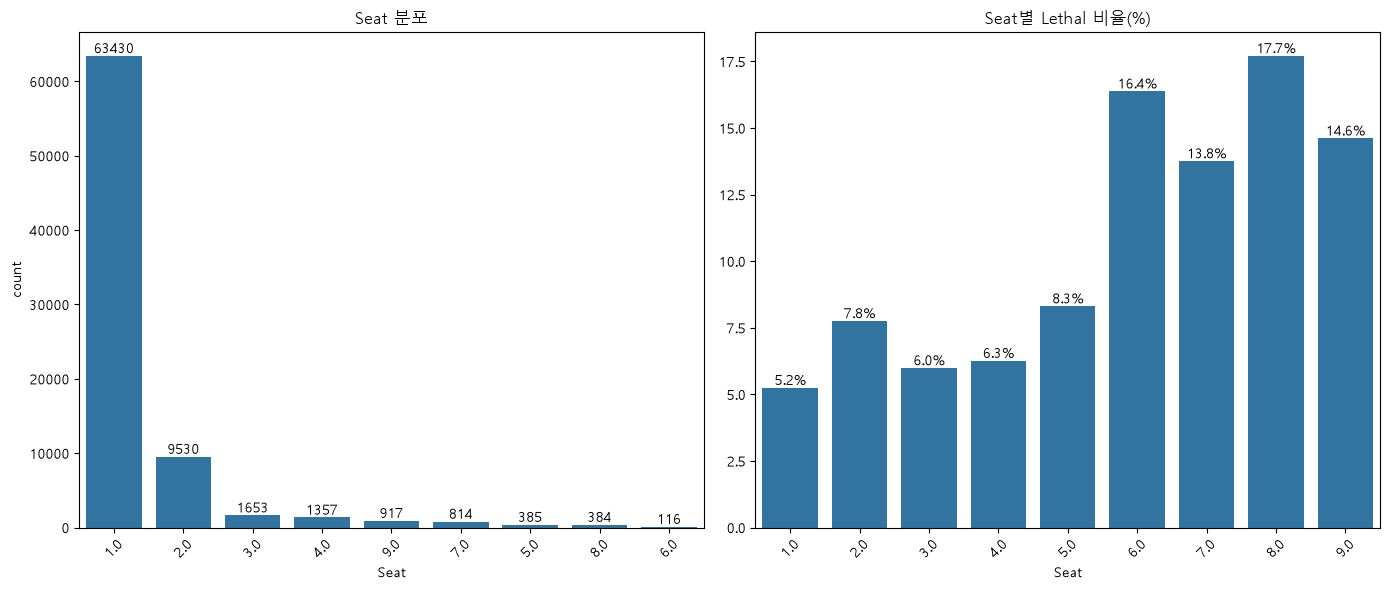

In [76]:
# 시각화
plot_category_vs_gravity(users_train, 'Seat')

- 좌석 번호 1~9를 나타내지만 결측치가 8,406건 존재한다.
- 결측 원인을 분석한 결과 단순 미기록이 아니라 두 가지 서로 다른 원인이 섞여 있다.
- **애초에 좌석 개념이 적용되지 않는 보행자 이거나 실제 탑승자인데 좌석 값이 기록되지 않은 케이스이다.**
- 이 그룹들을 구분하여 라벨을 재정의한다.

In [77]:
# 추가 보행자 운전자 교정
idx_pedestrian_like = 54094  # 실제로는 보행자로 보이는 사람
idx_driver_like = 54095      # 실제로는 운전자로 보이는 사람

# Seat 값 스왑
users_train.loc[idx_pedestrian_like, 'Seat'] = None
users_train.loc[idx_driver_like, 'Seat'] = 1.0

# 확인
print(users_train.loc[[idx_pedestrian_like, idx_driver_like],
      ['AccidentId','VehicleId','Seat','PedestrianLocation','PedestrianAction','PedestrianCompany']])

         AccidentId VehicleId  Seat       PedestrianLocation PedestrianAction  \
54094  201800035894       A01   NaN  OnCrossingWithoutLights         Crossing   
54095  201800035894       A01   1.0                      NaN              NaN   

      PedestrianCompany  
54094             Alone  
54095               NaN  


- 보행자 컬럼 조사중 Driver로 되어있으나 보행자 정보가 있어 확인하던 중 두개의 Seat값이 잘못입력되었다고 판단되어 수정하였다.

In [78]:
# 보행자 판별 (Company는 Unknown 제외, 의미있는 값만 인정)
users_train['is_pedestrian'] = (
    users_train['PedestrianLocation'].notna() |
    users_train['PedestrianAction'].notna() |
    users_train['PedestrianCompany'].isin(['Alone', 'WithSomebody', 'WithGroup']))

# 그룹 키 설정
group_key = ['AccidentId', 'VehicleId']

#이미 Seat==1로 확정된 운전자가 있는 그룹 지정하기
driver_groups = set(users_train.loc[users_train['Seat'] == 1, group_key].apply(tuple, axis=1))

# Seat 결측 + 보행자 아닌 케이스 = 처리 대상
target_mask = users_train['Seat'].isna() & (~users_train['is_pedestrian'])

# 그룹별 target 인원 수 추출
group_size = users_train.loc[target_mask].groupby(group_key)[group_key[0]].transform('size')
users_train.loc[target_mask, 'target_group_size'] = group_size

In [79]:
# 최종 RoadUserType 생성하여 라벨링 함수 생성하기
def get_role(row):
    if pd.notna(row['Seat']):
        return 'Driver' if float(row['Seat']) == 1 else 'Passenger'
    elif row['is_pedestrian']:
        return 'Pedestrian'
    key = (row['AccidentId'], row['VehicleId'])
    if key in driver_groups:
        return 'Passenger'          # 이미 운전자가 있으면 무조건 동승자로 (변경하지 않음)
    elif row.get('target_group_size') == 1:
        return 'Driver'
    else:
        return 'Unknown'

users_train['RoadUserType'] = users_train.apply(get_role, axis=1)
print(users_train['RoadUserType'].value_counts(dropna=False))

RoadUserType
Driver        64652
Passenger     15349
Pedestrian     6987
Unknown           4
Name: count, dtype: int64


- 보행자 관련 컬럼 ['PedestrianLocation', 'PedestrianAction','PedestrianCompany']을 이용하여 하나라도 값이 존재하면 보행자로 분류하였다. (보행자에게만 존재하는 값)
- 남은 결측 인원에 대해서는 [AccidentId, VehicleId] 그룹 단위로 재분류하였다
  - 그룹 내 결측 인원이 1명뿐이고 운전자 값이 존재하지 않는다면 운전자로 구분한다.
  - 이외 매칭이 안되는 데이터는 Unknown으로 처리한다.
- 또한 기존의 라벨링의 값을 수정하여 uers_train['RoadUserType'] 컬럼에 `Driver`, `Passenger`, `Pedestrian`,`Unknown` 네개의 범주로 통일하였다. (뒷 부분에서 집계데이터 진행시 유리하다)

In [80]:
# Test 데이터에도 적용
def build_road_user_type(df):
    df = df.copy()
    
    # 보행자 판별
    df['is_pedestrian'] = (
        df['PedestrianLocation'].notna() |
        df['PedestrianAction'].notna() |
        df['PedestrianCompany'].isin(['Alone', 'WithSomebody', 'WithGroup'])
    )
    
    group_key = ['AccidentId', 'VehicleId']
    
    # 이미 Seat==1로 확정된 운전자가 있는 그룹
    driver_groups = set(df.loc[df['Seat'] == 1, group_key].apply(tuple, axis=1))
    
    # Seat 결측 + 보행자 아닌 케이스 = 처리 대상
    target_mask = df['Seat'].isna() & (~df['is_pedestrian'])
    
    # 그룹별 target 인원 수
    group_size = df.loc[target_mask].groupby(group_key)[group_key[0]].transform('size')
    df.loc[target_mask, 'target_group_size'] = group_size
    
    def get_role(row):
        if pd.notna(row['Seat']):
            return 'Driver' if float(row['Seat']) == 1 else 'Passenger'
        elif row['is_pedestrian']:
            return 'Pedestrian'
        key = (row['AccidentId'], row['VehicleId'])
        if key in driver_groups:
            return 'Passenger'
        elif row.get('target_group_size') == 1:
            return 'Driver'
        else:
            return 'Unknown'
    
    df['RoadUserType'] = df.apply(get_role, axis=1)
    return df

# test 적용
users_test = build_road_user_type(users_test)
print("\ntest:")
print(users_test['RoadUserType'].value_counts(dropna=False))


test:
RoadUserType
Driver        16310
Passenger      3837
Pedestrian     1699
Name: count, dtype: int64


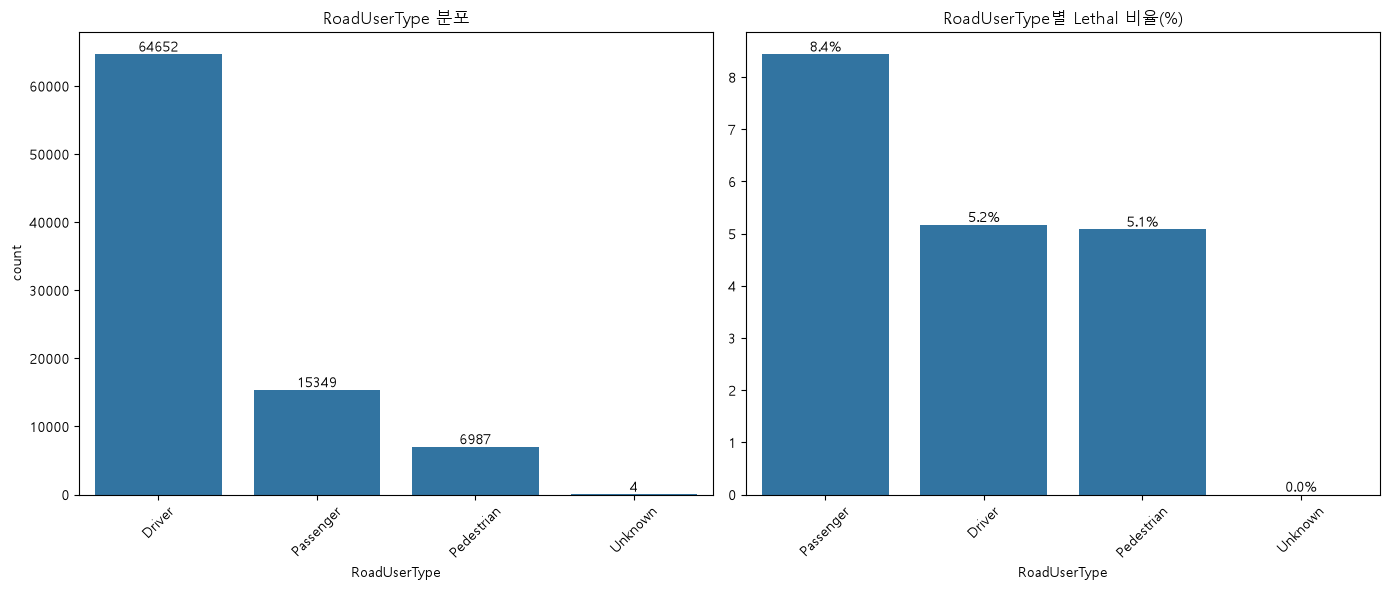

In [81]:
# 라벨 재정의 후 시각화
plot_category_vs_gravity(users_train, 'RoadUserType')

#### Gender 컬럼 분석 (성별)

In [82]:
users_train['Gender'].isna().sum()

np.int64(1205)

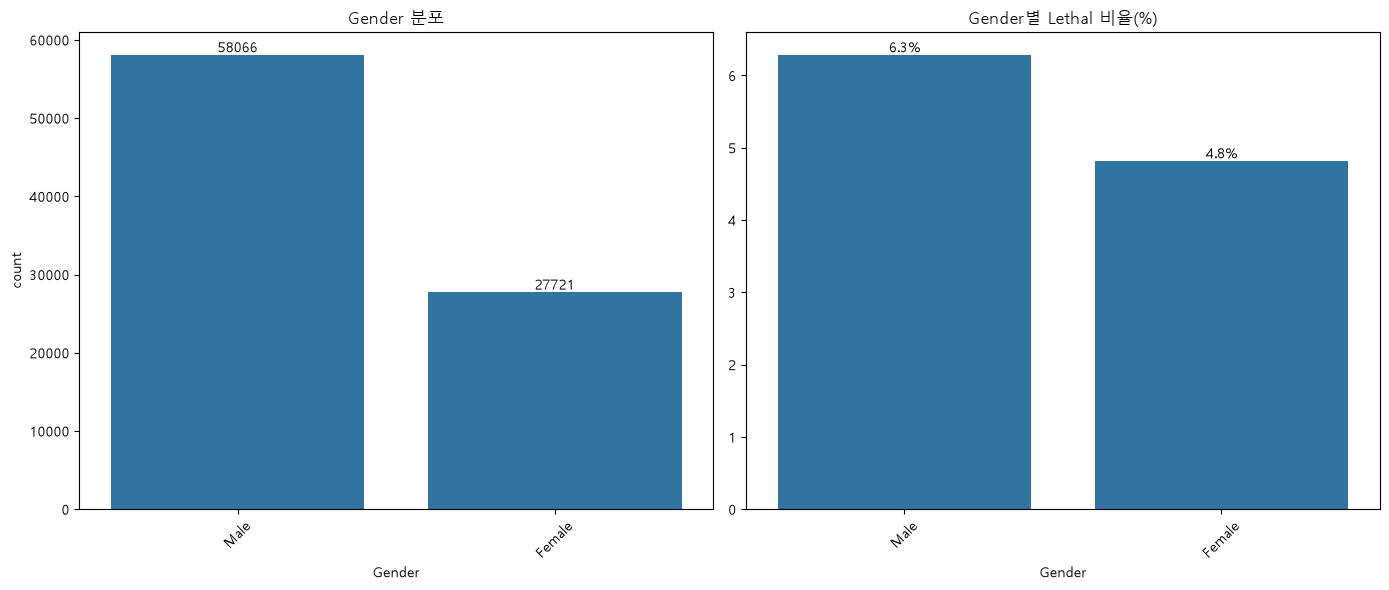

In [83]:
# 시각화
plot_category_vs_gravity(users_train, 'Gender')

- 결측치 1205건이 발생되었다. 성별의 경우 관측이 되지 않았거나 누락된 값으로 알 수 없는 상태가 되므로 Unknown 라벨로 분류한다.
- 또한 남성 치명율이 더 높게 측정되었다. 이는 단순히 표본이 많아서라기 보다 실제로 남성쪽에 치명적 사고 비율 자체가 유의미하게 높다는 뜻으로 해석하였다.

In [84]:
# 결측치 값 수정
users_train['Gender'] = users_train['Gender'].fillna('Unknown')
users_test['Gender'] = users_test['Gender'].fillna('Unknown')

#### TripReason 컬럼 분석(이동 사유)

In [85]:
users_train['TripReason'].isna().sum()

np.int64(19894)

In [86]:
# 결측치 Unknown 처리
users_train['TripReason'] = users_train['TripReason'].fillna('Unknown')
users_test['TripReason'] = users_test['TripReason'].fillna('Unknown')

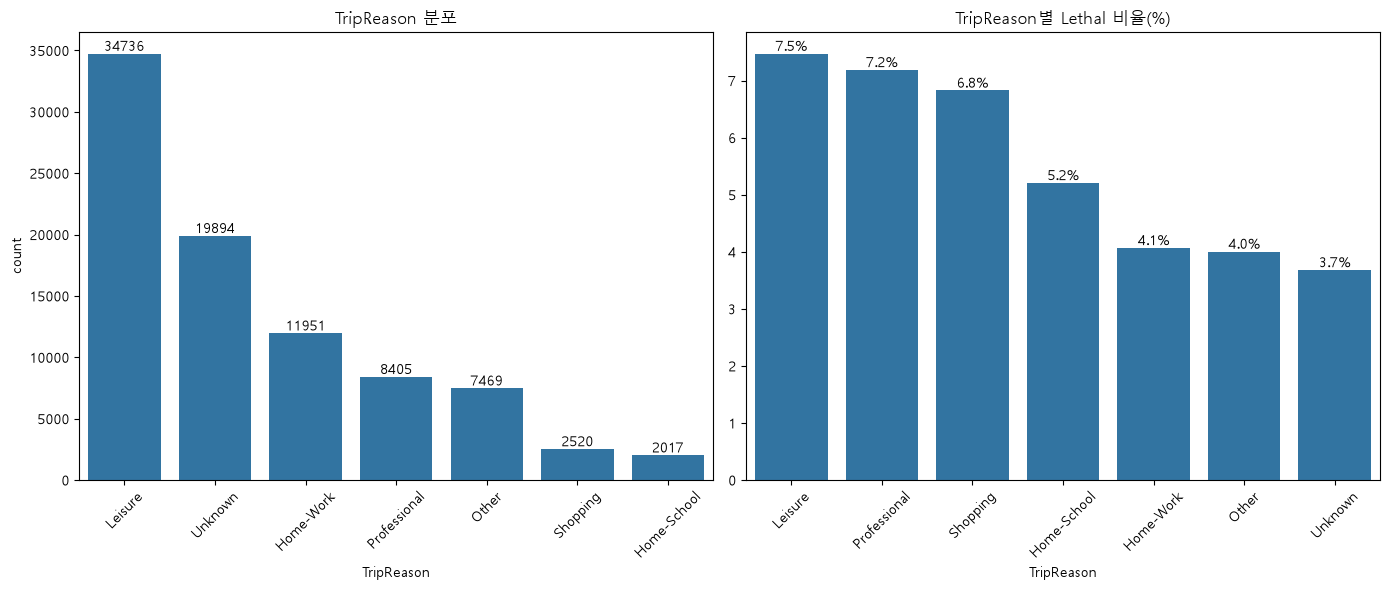

In [87]:
# 시각화
plot_category_vs_gravity(users_train, 'TripReason')

- 결측치의 경우 Unknown 라벨로 재정의하였다.
- 분포와 Lethal 비율을 확인해보면 출퇴근/등하교는 상대적으로 저속 근거리 이동으로 볼 수 있고 치명율이 낮게 확인되었다.
- 하지만 여행이나 출퇴근의 경우 장거리, 고속도로 주행, 야간 이동 가능성이 높은 목적은 치명율이 높은것으로 확인되었다.

#### SafetyDevice, SafetyDeviceUsed 컬럼 분석 (안전장치 종류, 안전장치 착용여부)

In [88]:
users_train['SafetyDevice'].isna().sum()

np.int64(3934)

In [89]:
users_train['SafetyDeviceUsed'].isna().sum()

np.int64(10413)

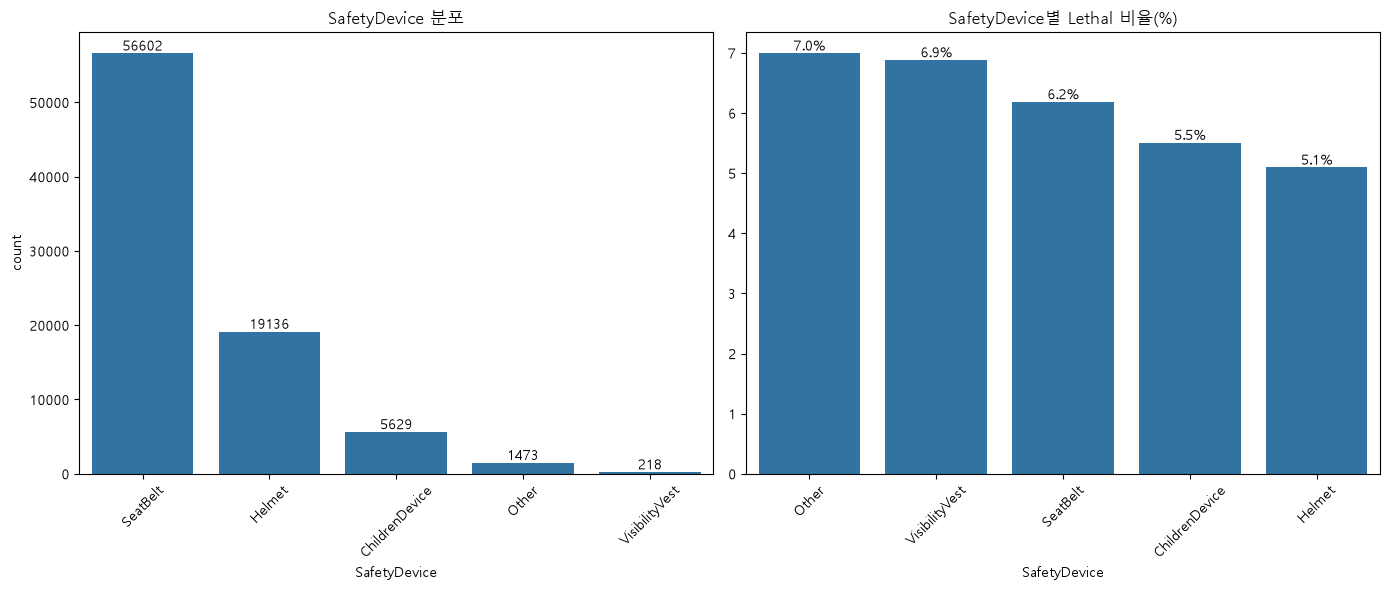

In [90]:
# 시각화
plot_category_vs_gravity(users_train, 'SafetyDevice')

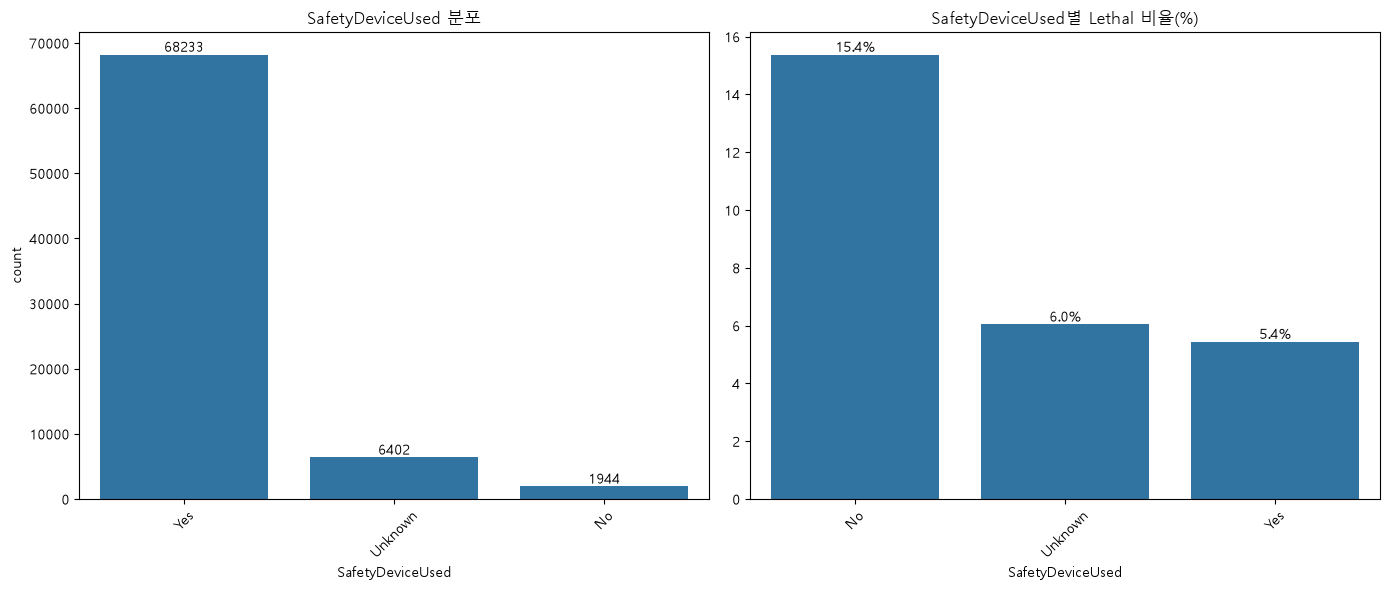

In [91]:
# 시각화
plot_category_vs_gravity(users_train, 'SafetyDeviceUsed')

In [92]:
pd.crosstab(
    users_train['SafetyDeviceUsed'],
    users_train['SafetyDevice'].isna().map({False: '라벨있음', True: '결측치'}),
    dropna=False)

SafetyDevice,결측치,라벨있음
SafetyDeviceUsed,,
No,0,1944
Unknown,0,6402
Yes,0,68233
NaN,3934,6479


- 둘의 결측치를 재정의를 위해 두 관계를 살펴보았다.
- 위 표에서 False = SafetyDevice 값이 있는 경우이고, True는 결측치인 경우이다.
- 첫번째 행 데이터를 확인해보면 SaretyDevice 값이 존재하면서 SafetyDeviceUsed(안전밸트 착용여부)가 No인 케이스가 있다.
- **이것은 SafetyDevice에 안전장치의 종류만을 입력한것이며 착용 여부에 대해 입력된 데이터가 아니라는 것이다.**
- 또한 SafetyDevice가 NaN인경우 SafetyDeviceUsed도 NaN이였으며 이 값은 확실한 결측치로 라벨을 'Missing'으로 교체한다.

In [93]:
# 결측치 처리하기
users_train['SafetyDevice'] = users_train['SafetyDevice'].fillna('Missing')
users_train['SafetyDeviceUsed'] = users_train['SafetyDeviceUsed'].fillna('Missing')

# test적용
users_test['SafetyDevice'] = users_test['SafetyDevice'].fillna('Missing')
users_test['SafetyDeviceUsed'] = users_test['SafetyDeviceUsed'].fillna('Missing')

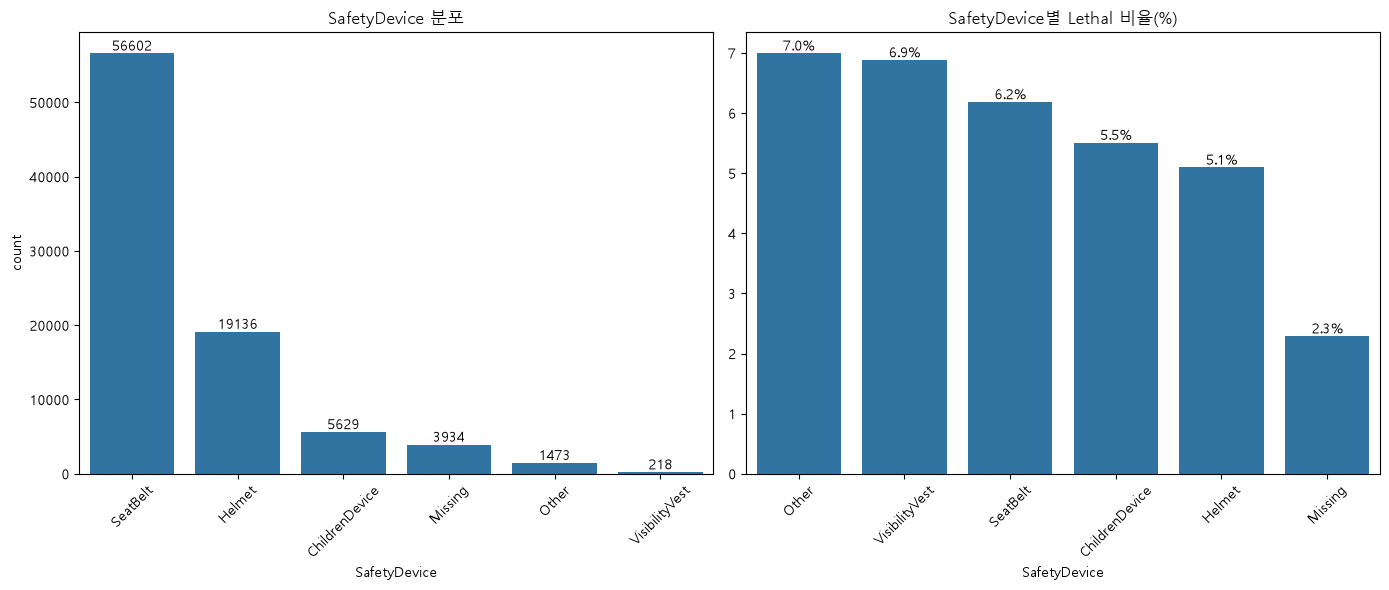

In [94]:
# 라벨 정의 후 분포 재확인
plot_category_vs_gravity(users_train, 'SafetyDevice')

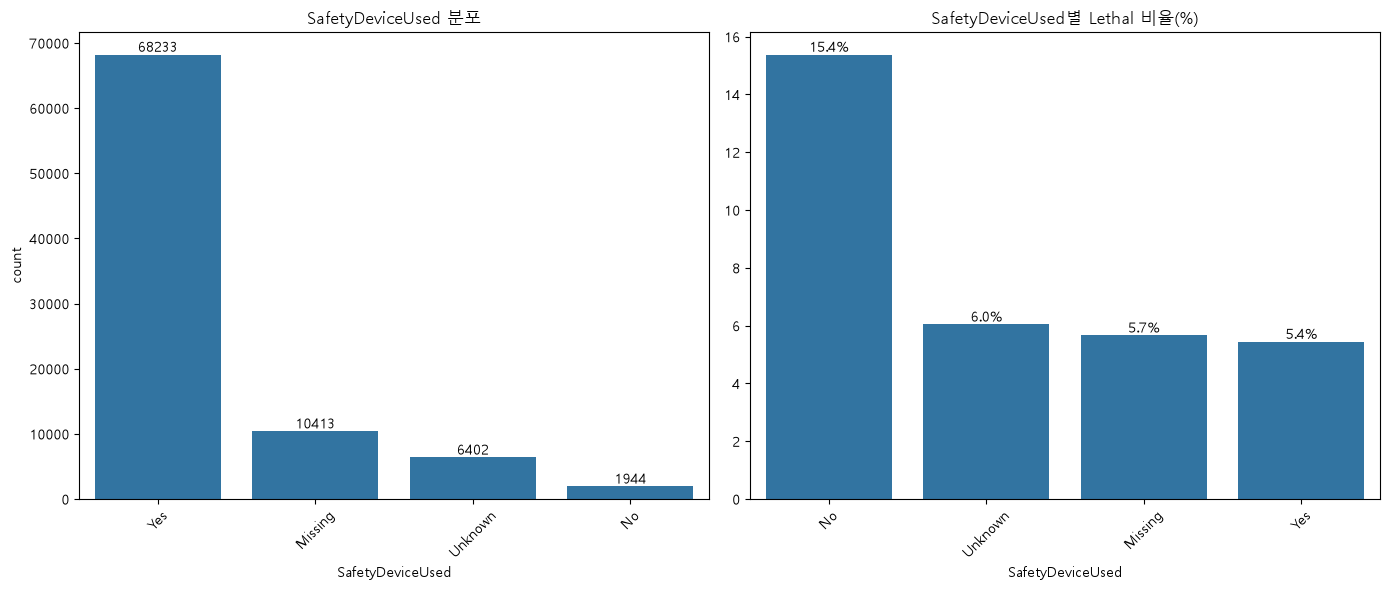

In [95]:
# 라벨 정의 후 분포 재확인
plot_category_vs_gravity(users_train, 'SafetyDeviceUsed')

#### PedestrianLocation,PedestrianAction,PedestrianCompany 컬럼 분석 (보행자 관련 컬럼)

* 세 컬럼 모두 결측인 경우는 보행자가 아닌 것으로 확인되었다.
* PedestrianLocation, PedestrianAction 중 하나라도 값이 있으면 보행자이다.
* PedestrianCompany는 비보행자에게도 'Unknown'이 다수 채워져 있어 'Unknown'을 제외한 실제 값(Alone/WithSomebody/WithGroup)이 있는 경우만 보행자 판별에 사용하였다.
* 검증 과정에서 Seat와 보행자 정보가 동시에 기록된 모순 사례 1건을 발견하여 원본 값을 교정하였다. (Seat 컬럼처리에서 확인 가능)
* 추후 Users 데이터셋은 집계 데이터셋으로 Accidents 데이터셋과 병합할 예정으로 집계에 용이하도록 보행자 여부를 나타내는 이진 플래그(is_pedestrian)를 생성한다.

In [96]:
# 보행자 여부 이진 플래그 생성
users_train['is_pedestrian'] = (users_train['RoadUserType'] == 'Pedestrian').astype(int)
users_test['is_pedestrian'] = (users_test['RoadUserType'] == 'Pedestrian').astype(int)

print(users_train['is_pedestrian'].value_counts())

is_pedestrian
0    80005
1     6987
Name: count, dtype: int64


In [97]:
# 결측치 처리
users_train['PedestrianLocation'] = users_train['PedestrianLocation'].fillna('Not_Applicable')
users_train['PedestrianAction'] = users_train['PedestrianAction'].fillna('Not_Applicable')
users_train['PedestrianCompany'] = users_train['PedestrianCompany'].fillna('Unknown')

users_test['PedestrianLocation'] = users_test['PedestrianLocation'].fillna('Not_Applicable')
users_test['PedestrianAction'] = users_test['PedestrianAction'].fillna('Not_Applicable')
users_test['PedestrianCompany'] = users_test['PedestrianCompany'].fillna('Unknown')

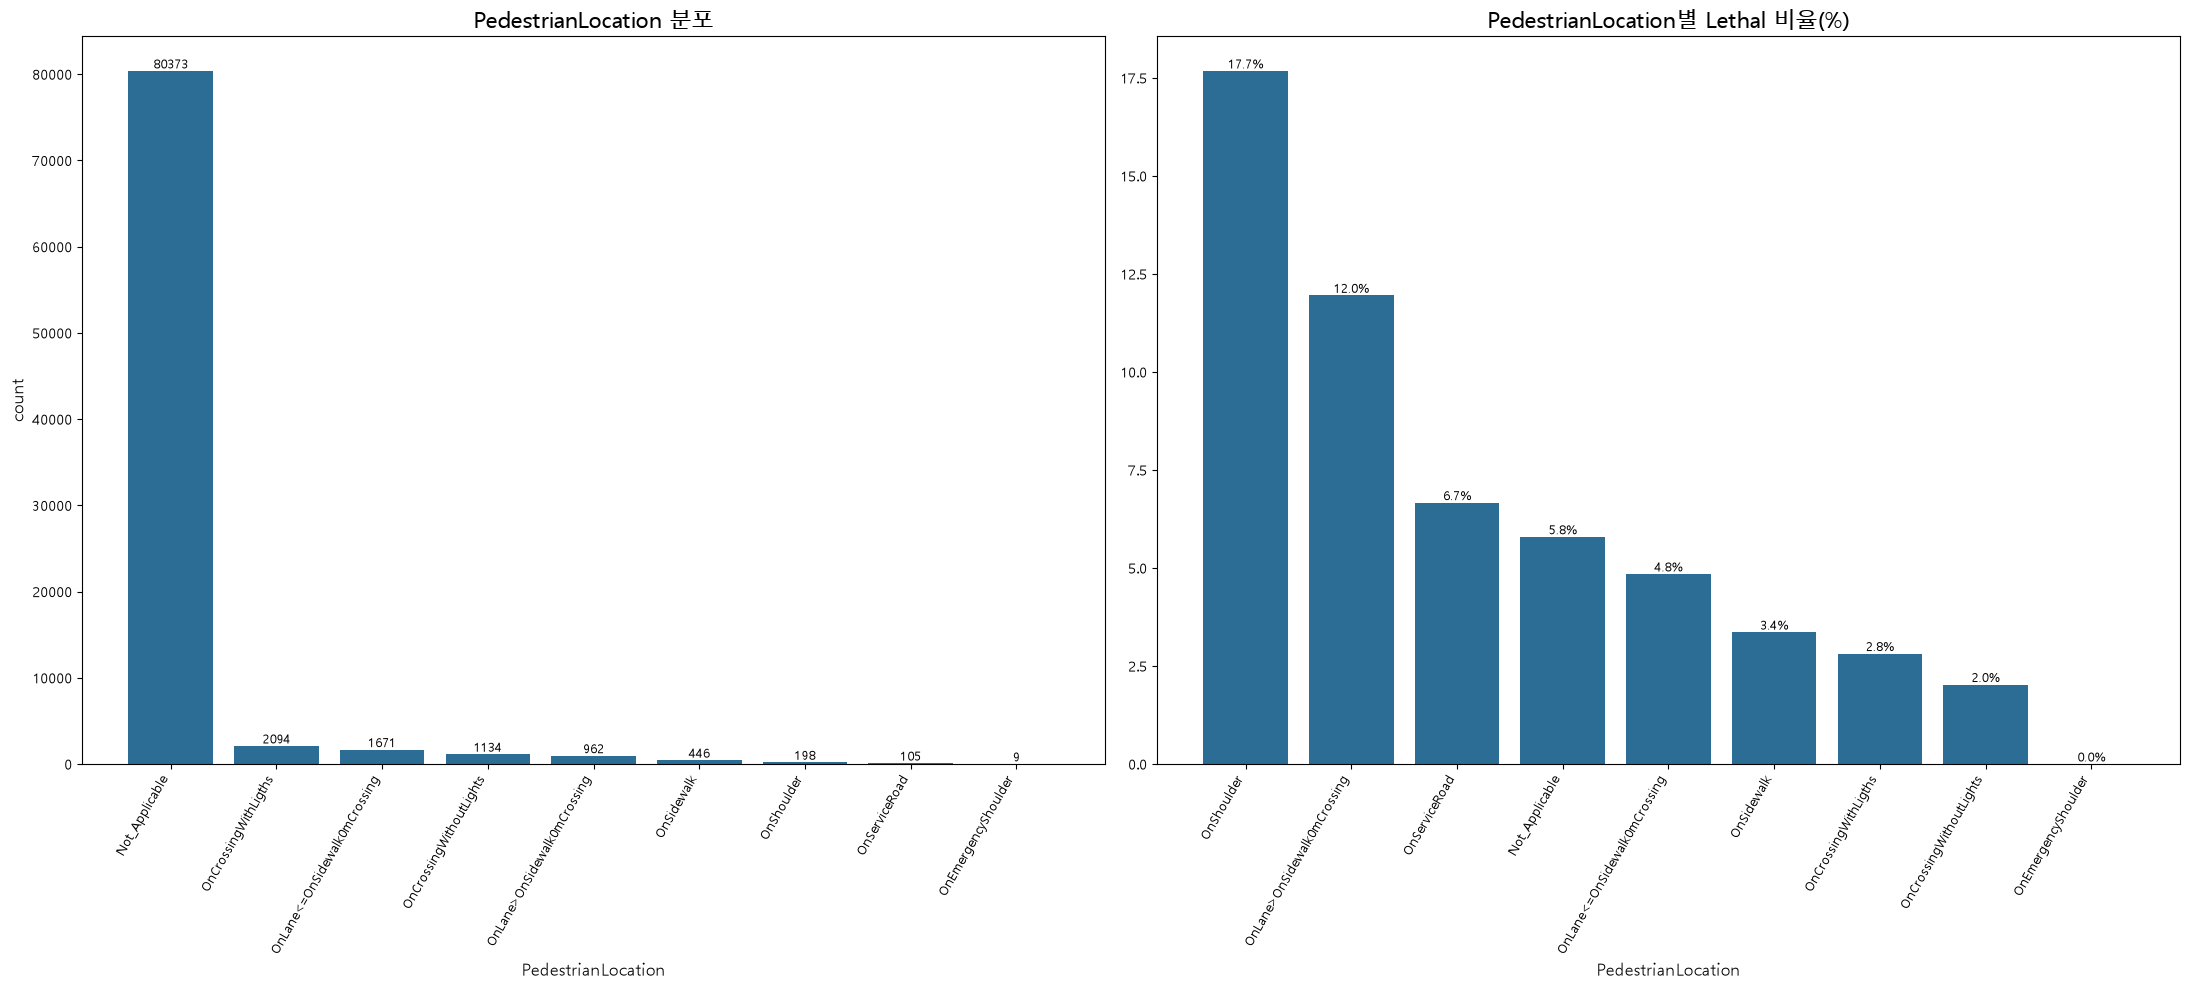

In [98]:
# PedestrianLocation 분포 시각화
col = 'PedestrianLocation'

fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# 분포
counts = users_train[col].value_counts()
bars = axes[0].bar(counts.index.astype(str), counts.values, color='#2b6d94')
axes[0].set_title(f'{col} 분포', fontsize=16)
axes[0].set_xlabel(col, fontsize=12)
axes[0].set_ylabel('count', fontsize=12)
axes[0].tick_params(axis='x', rotation=60, labelsize=9)
for label in axes[0].get_xticklabels():
    label.set_ha('right')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val}', ha='center', va='bottom', fontsize=9)

# Lethal 비율
lethal_rate = (
    users_train.groupby(col)['Gravity']
    .apply(lambda x: (x == 'Lethal').mean() * 100)
    .sort_values(ascending=False)
)
bars2 = axes[1].bar(lethal_rate.index.astype(str), lethal_rate.values, color='#2b6d94')
axes[1].set_title(f'{col}별 Lethal 비율(%)', fontsize=16)
axes[1].set_xlabel(col, fontsize=12)
axes[1].tick_params(axis='x', rotation=60, labelsize=9)
for label in axes[1].get_xticklabels():
    label.set_ha('right')
for bar, val in zip(bars2, lethal_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

- 전체의 대부분이 보행자가 아닌 Not_Applicable이며 실제 보행자 위치 정보는 소수에 집중되어있다.
- 신호등 있는 횡단보도(OnCrossingWithLights) 사고가 가장 많지만 치명율은 오히려 갓길(OnShoulder, 17.7%)이 가장 높아 도로변 고속 구간일수록 위험도가 커짐을 보여준다.

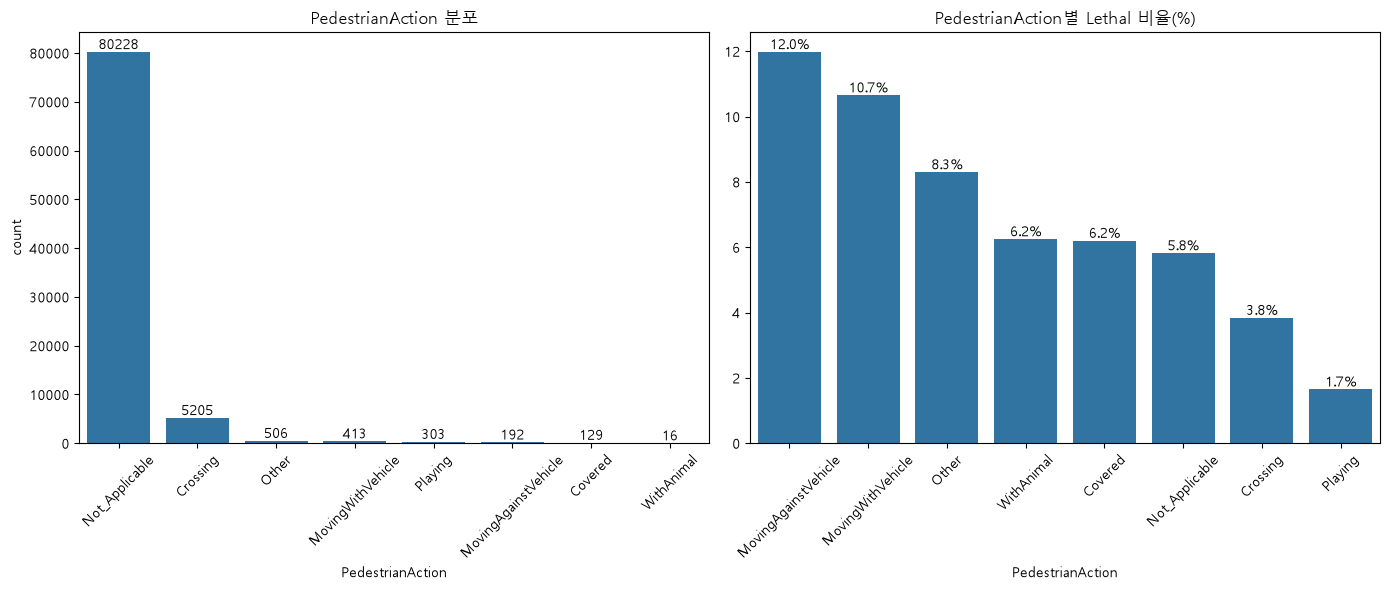

In [99]:
# PedestrianAction 분포 시각화
plot_category_vs_gravity(users_train, 'PedestrianAction')

- 대부분이 Not_Applicable이며 실제 보행자 행동 중에서는 Crossing-횡단이 가장 많다.
- 차량 진행 방향과 반대로 이동-MovingAgainstVehicle 또는 같은 방향으로 이동 - MovingWithVehicle 한 경우가 단순 횡단 보다 치명율이 높아 차도 위 이동 자체가 위험 요인이라는것을 알 수 있었다.

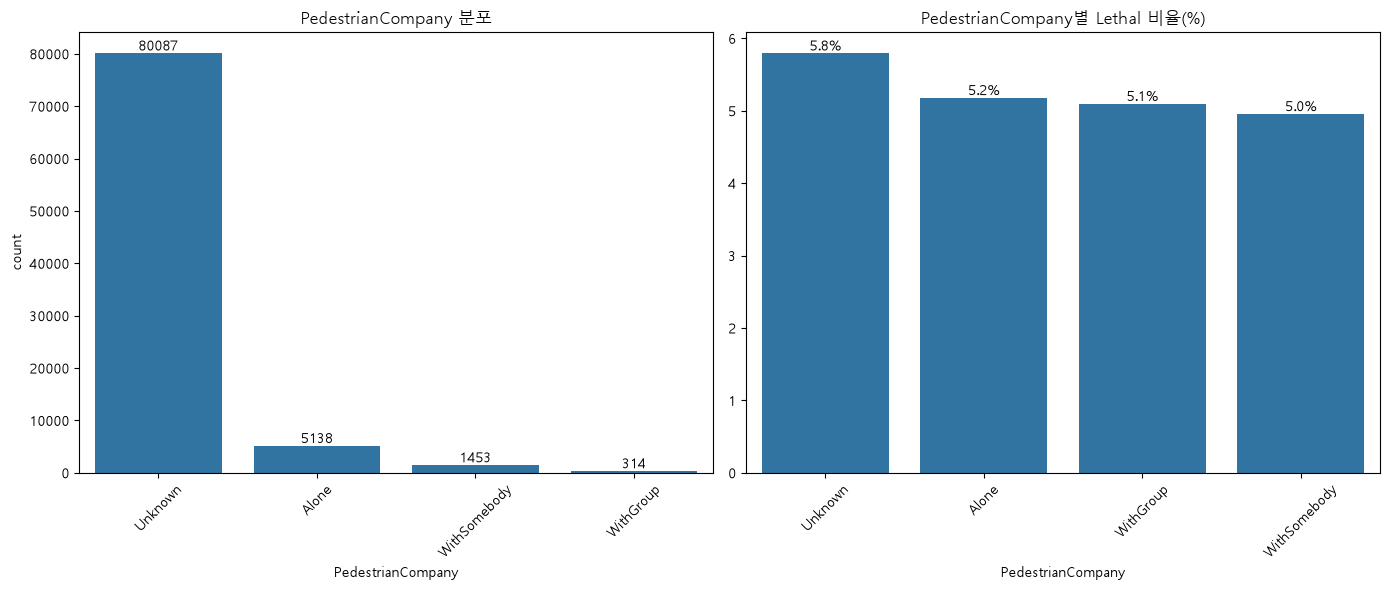

In [100]:
# PedestrianCompany 분포 시각화
plot_category_vs_gravity(users_train, 'PedestrianCompany')

- 대부분 Unknown 라벨이며 실제 응답이 있는 경우 Alone이였던 경우가 가장 많았다.
- 동행 여부에 따른 치명율 차이는 5.0 - 5.8% 수준으로 크지 않으며 다른 보행자 변수에 비해 치명율과의 연관성은 약한 편이라고 할 수 있다.

#### BirthYear 컬럼 분석 (출생년도)

In [101]:
users_train['BirthYear'].isna().sum()

np.int64(2996)

In [102]:
# 출생년도를 나이로 변환하여 Age 컬럼에 저장하기
users_train['Age'] = 2018 - users_train['BirthYear']
users_train['Age_missing_flag'] = users_train['Age'].isna().astype(int)
users_train['Age'] = users_train['Age'].fillna('Unknown')

# 소수점 정리하기 'Unknown'이 아닌 값만 정수로 변환
users_train['Age'] = users_train['Age'].apply(lambda x: int(x) if x != 'Unknown' else x)

# test 적용
users_test['Age'] = 2018 - users_test['BirthYear']
users_test['Age_missing_flag'] = users_test['Age'].isna().astype(int)
users_test['Age'] = users_test['Age'].fillna('Unknown')
users_test['Age'] = users_test['Age'].apply(lambda x: int(x) if x != 'Unknown' else x)

- `2018 - BirthYear`로 나이를 계산해 `Age` 컬럼 생성 (사고 연도가 2018년으로 고정)
- 결측치는 -1 등 임의의 숫자 대신 `'Unknown'`으로 처리하여 집계 시 값 왜곡 방지
- 결측 여부를 추적할 수 있도록 `Age_missing_flag` 컬럼 별도 생성
- 추후 집계 데이터셋 생성 시 `Age`를 연령대 그룹으로 나눠 사용할 예정

In [103]:
# 나이를 범위로 묶기
# 'Unknown'을 임시로 NaN 처리해서 구간화 이후 다시 'Unknown'으로 복원
age_numeric = pd.to_numeric(users_train['Age'], errors='coerce')

bins = [-1, 10, 20, 30, 40, 50, 60, 70, np.inf]
labels = ['le_10', 'le_20', 'le_30', 'le_40', 'le_50', 'le_60', 'le_70', '70+']

users_train['AgeGroup'] = pd.cut(age_numeric, bins=bins, labels=labels, right=True)
# Age가 원래 'Unknown'이었던 행은 AgeGroup도 'Unknown'으로
users_train['AgeGroup'] = users_train['AgeGroup'].astype('object')
users_train.loc[users_train['Age'] == 'Unknown', 'AgeGroup'] = 'Unknown'

print(users_train['AgeGroup'].value_counts(dropna=False))

AgeGroup
70+        17772
le_30      14528
le_40      11530
le_50      10653
le_60      10502
le_70       8067
le_20       7857
le_10       3087
Unknown     2996
Name: count, dtype: int64


In [104]:
# 임의의 연령구간으로 AgeGroup_2 생

def classify_age(age):
    if pd.isna(age):
        return 'Unknown'
    if age <= 8:
        return "child"
    elif age <= 19:
        return "youth"
    elif age <= 34:
        return "adult"
    elif age <= 65:
        return "senior"
    else:
        return "elder"

age_numeric = pd.to_numeric(users_train['Age'], errors='coerce')
users_train['AgeGroup_2'] = age_numeric.apply(classify_age)

print(users_train['AgeGroup_2'].value_counts(dropna=False))

AgeGroup_2
senior     31959
elder      21632
adult      21187
youth       6789
Unknown     2996
child       2429
Name: count, dtype: int64


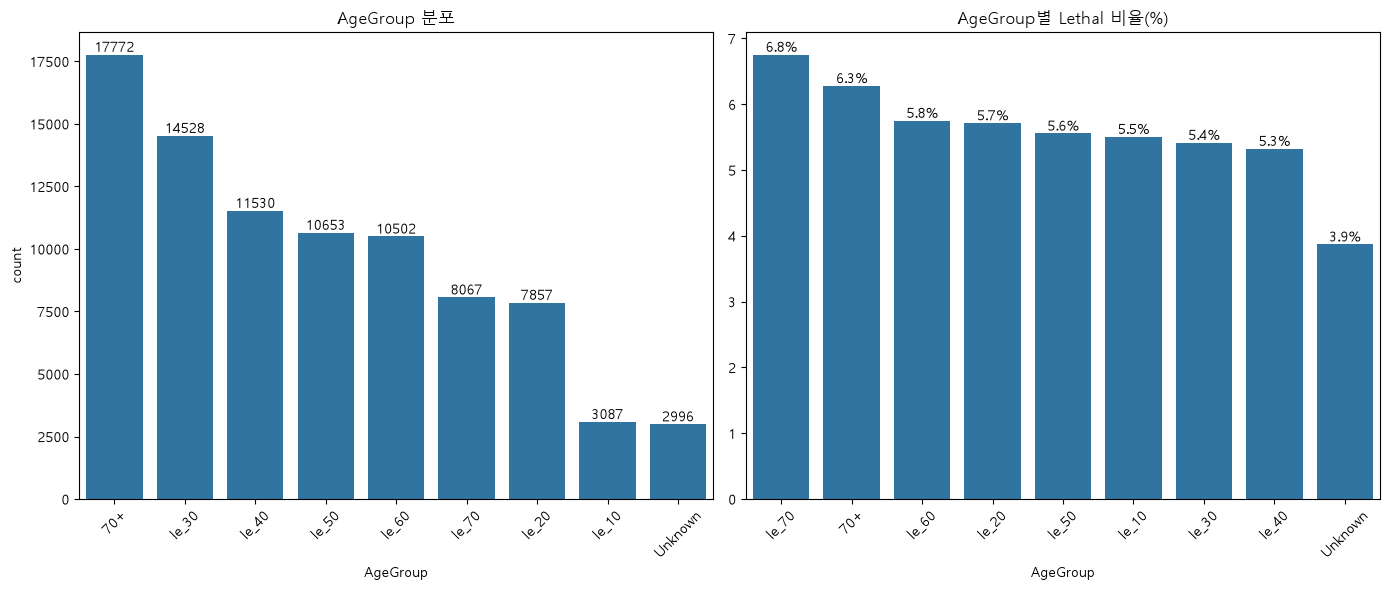

In [105]:
# 그룹화된 나이 분포 시각화
plot_category_vs_gravity(users_train, 'AgeGroup')

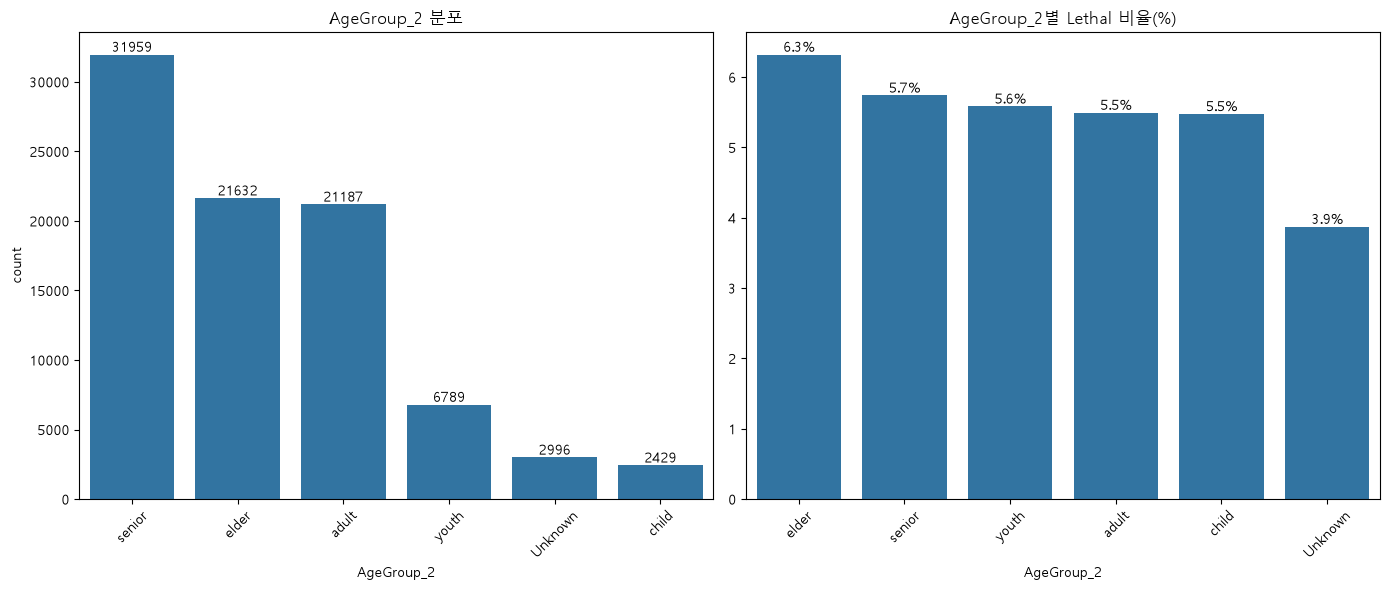

In [106]:
# 그룹화된 나이 분포 시각화
plot_category_vs_gravity(users_train, 'AgeGroup_2')

- AgeGroup_2 컬럼에서는 자연스럽게 고령일수록 Lethal 비율이 올라가는것으로 확인된다.
- 하지만 AgeGroup 컬럼에서는 70세이하가 70세초과 나이대에 비해 더 높게 나타난다.
- 이를 확인하기 위해 EDA를 조금 더 진행하였다.

In [107]:
# UsersType 컬럼 기준으로 비율 확인하기
pd.crosstab(users_train['AgeGroup'], users_train['RoadUserType'], normalize='index') * 100

RoadUserType,Driver,Passenger,Pedestrian,Unknown
AgeGroup,,,,
70+,72.991222,18.073374,8.929777,0.005627
Unknown,84.045394,10.380507,5.574099,0.000000
le_10,3.660512,68.318756,28.020732,0.000000
le_20,53.506427,35.280641,11.212931,0.000000
le_30,78.372797,16.774504,4.838932,0.013767
le_40,82.610581,11.734605,5.646141,0.008673
le_50,83.525767,10.081667,6.392565,0.000000
le_60,82.650924,10.521805,6.827271,0.000000
le_70,78.790133,12.098674,9.111194,0.000000


In [108]:
# 나이대별 UsersType으로 Lethal 비율 확인하기
pd.crosstab([users_train['AgeGroup'], users_train['RoadUserType']], users_train['Gravity'], normalize='index') * 100

Gravity                  Lethal   NonLethal
AgeGroup RoadUserType                      
70+      Driver        5.404364   94.595636
         Passenger     9.122042   90.877958
         Pedestrian    7.687461   92.312539
         Unknown       0.000000  100.000000
Unknown  Driver        3.057983   96.942017
         Passenger     9.324759   90.675241
         Pedestrian    5.988024   94.011976
le_10    Driver        2.654867   97.345133
         Passenger     7.444286   92.555714
         Pedestrian    1.156069   98.843931
le_20    Driver        4.305423   95.694577
         Passenger     8.621934   91.378066
         Pedestrian    3.291714   96.708286
le_30    Driver        4.883190   95.116810
         Passenger     7.714403   92.285597
         Pedestrian    6.125356   93.874644
         Unknown       0.000000  100.000000
le_40    Driver        4.998425   95.001575
         Passenger     7.766272   92.233728
         Pedestrian    5.069124   94.930876
         Unknown       0.000000  100.000000
le_50    Driver        5.102270   94.897730
         Passenger     9.972041   90.027959
         Pedestrian    4.552129   95.447871
le_60    Driver        5.587558   94.412442
         Passenger     7.963801   92.036199
         Pedestrian    4.323570   95.676430
le_70    Driver        6.450598   93.549402
         Passenger     9.118852   90.881148
         Pedestrian    6.258503   93.741497

**AgeGroup 인사이트: 나이-치명율 역전 현상**

- AgeGroup 단독 기준: `<=70`(6.8%)이 `70+`(6.3%)보다 치명율이 높은 역전 현상 발견 하였다.
- RoadUserType으로 분해
  - Driver: `<=70`이 `70+`보다 높다는 것을 확인 하였으며 운전자 행동 패턴 차이로 추정하였다.
  - Pedestrian: `70+`가 `<=70`보다 높음을 확인 하였으며 고령일수록 위험하다는 상식과 일치된다.
- 결론적으로 전체 역전은 Driver 비중이 높은 데이터 구조상 Driver 쪽 역전이 평균을 끌어올린 결과이다.

#### **AgeGroup 컬럼을 사용하기로 결정했다.**

In [109]:
# test 데이터 적용

age_numeric = pd.to_numeric(users_test['Age'], errors='coerce')

bins = [-1, 10, 20, 30, 40, 50, 60, 70, np.inf]
labels = ['le_10', 'le_20', 'le_30', 'le_40', 'le_50', 'le_60', 'le_70', '70+']

users_test['AgeGroup'] = pd.cut(age_numeric, bins=bins, labels=labels, right=True)
users_test['AgeGroup'] = users_test['AgeGroup'].astype('object')
users_test.loc[users_test['Age'] == 'Unknown', 'AgeGroup'] = 'Unknown'

In [110]:
# AgeGroup_2 컬럼 삭제
users_train = users_train.drop(columns=['AgeGroup_2'])

## vehicles 데이터 셋

In [111]:
vehicles_train.isna().sum()

AccidentId             0
Direction             75
PassengerNumber        0
FixedObstacle      54065
MobileObstacle     11482
ImpactPoint         3427
Maneuver            4992
dtype: int64

In [112]:
# 분석을 위해 Gravity 컬럼을 places_Train에 merge
vehicles_train = vehicles_train.merge(
    accidents_train[['AccidentId', 'Gravity']],
    on='AccidentId',
    how='left')

#### PassengerNumber 컬럼 (탑승자 수)

In [113]:
vehicles_train['PassengerNumber'].unique()

array([  0,   1,   3,  45,   2,  21,  10,  31,   5,  49,  52,  12,   7,
        50,  46,  42,  20,   6,   4,  30,  28,  16,  41,  13,  39,  44,
        38,  64,  19,   8,  25,  54,  18,   9,  48,  59,  11,  15, 100,
        40, 128, 153,  47,  36,  60,  22,  77,  26,  62,  29,  57, 200,
        35, 120,  17,  24,  53,  66,  43,  55,  75,  70, 105,  51,  33,
        71,  23,  78,  27])

- 해당 컬럼의 경우 0명이 있거나 정확한 탑승 인원을 파악하기가 어려운 데이터로 확인된다.
- users 데이터 셋에서 충분히 탑승 인원을 알 수 있기 때문에 해당 컬럼은 삭제처리한다.

In [114]:
vehicles_train = vehicles_train.drop(columns=['PassengerNumber'])
vehicles_test = vehicles_test.drop(columns=['PassengerNumber'])

#### Direction 컬럼 분석 (방향)

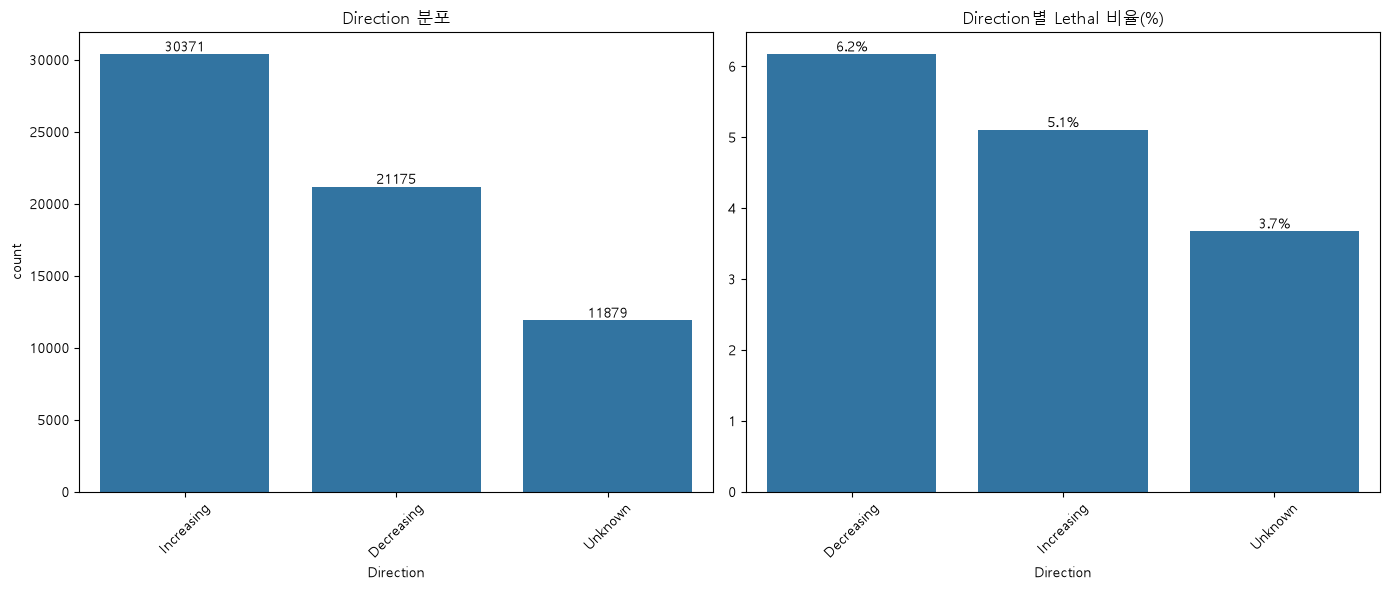

In [115]:
# 분포 시각화
plot_category_vs_gravity(vehicles_train,'Direction')

- 결측치 75개가 존재하고 있어 작은 수로 알 수 없는 값으로 Unknown으로 합친다.
- 결측치 Unknown으로 처리하고 분포 재확인한다.

In [116]:
vehicles_train['Direction'] = vehicles_train['Direction'].fillna('Unknown')
vehicles_test['Direction'] = vehicles_test['Direction'].fillna('Unknown')

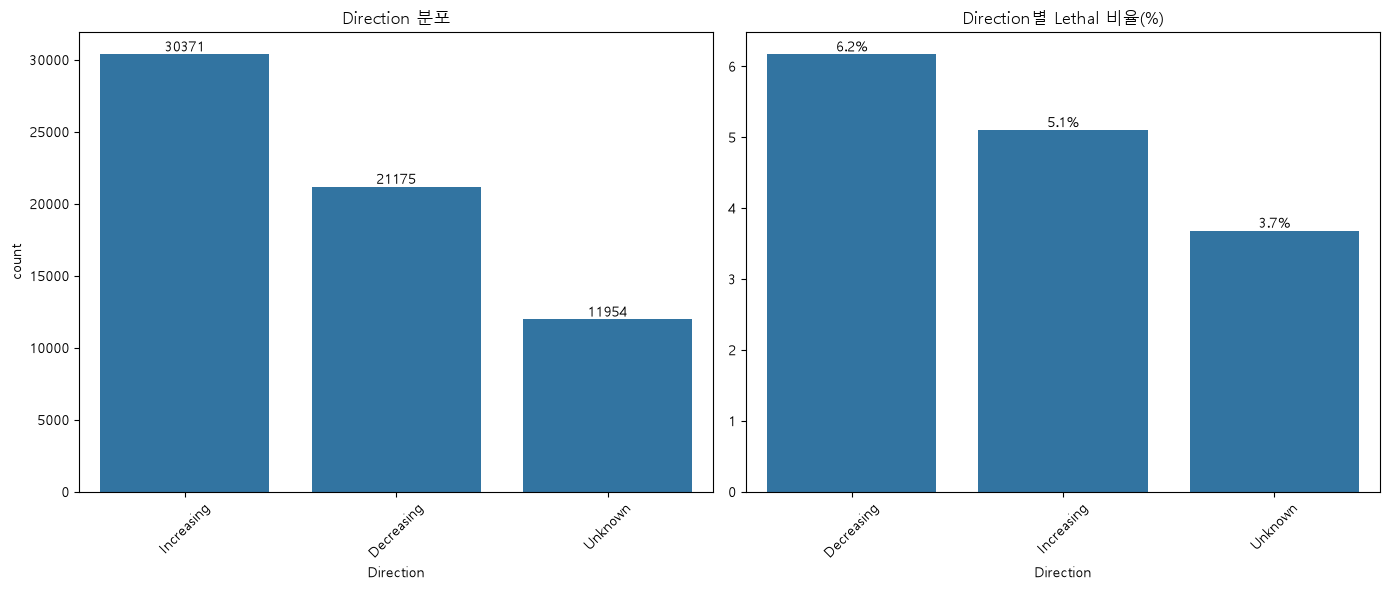

In [117]:
# 분포 시각화
plot_category_vs_gravity(vehicles_train,'Direction')

- 결측치 75개의 데이터가 Unknown으로 포함되었지만 Lethal 비율의 변화가 없어 이를 유지한다.

#### FixedObstacle, MobileObstacle 컬럼 분석 (고정 장애물 충돌, 이동 장애물 충돌)

In [118]:
print(vehicles_train['FixedObstacle'].isna().sum())
print(vehicles_train['MobileObstacle'].isna().sum())

54065
11482


- 결측치는 기록 누락이거나 애초에 해당 없음일 수 있다.
- 결측 비율이 높다면 고정 장애물 충돌이 아니였던 사고가 대부분이라는 구조일 가능성이 크다.

In [119]:
# 결측 비율 확인
print(vehicles_train['FixedObstacle'].isna().sum() / len(vehicles_train) * 100, "%")

85.14173228346456 %


- FixedObstacle의 결측 비율이 85%이상인것으로 보아 애초에 해당 사항이 없는 경우가 대부분이라고 해석해볼 수 있다.
- 아래에서 추가적으로 교차검증을 진행한다.

In [120]:
# 이동 장애물과 비교
pd.crosstab(vehicles_train['FixedObstacle'].isna(), vehicles_train['MobileObstacle'].isna())

MobileObstacle,False,True
FixedObstacle,,
False,2400,7035
True,49618,4447


- 두 컬럼을 교차 확인한 결과 둘 다 값이 있는 경우가 2,400건으로 존재해 완전한 배타 관계는 아님을 확인하였다.
- 대부분은 이동 장애물과만 충돌한 49,618건으로 확인되었으며 고정 장애물과만 충돌한 7,035건이있거나 둘 다 없는 경우 4,447건 단독사고 등도 존재한다.

In [121]:
# FixedObstacle, MobileObstacle 결측치 처리
vehicles_train['FixedObstacle'] = vehicles_train['FixedObstacle'].fillna('Not_Applicable')
vehicles_train['MobileObstacle'] = vehicles_train['MobileObstacle'].fillna('Not_Applicable')

#test 적용
vehicles_test['FixedObstacle'] = vehicles_test['FixedObstacle'].fillna('Not_Applicable')
vehicles_test['MobileObstacle'] = vehicles_test['MobileObstacle'].fillna('Not_Applicable')

- FixedObstacle, MobileObstacle 결측치는 해당 유형의 장애물과 충돌하지 않은 정상적인 경우로 판단하여 `Not_Applicable`로 처리하였다.
- 조사 누락이 아니라 애초에 해당 사항이 없는 구조적 결측이므로 별도 카테고리로 구분하는것으로 결정 하였다.

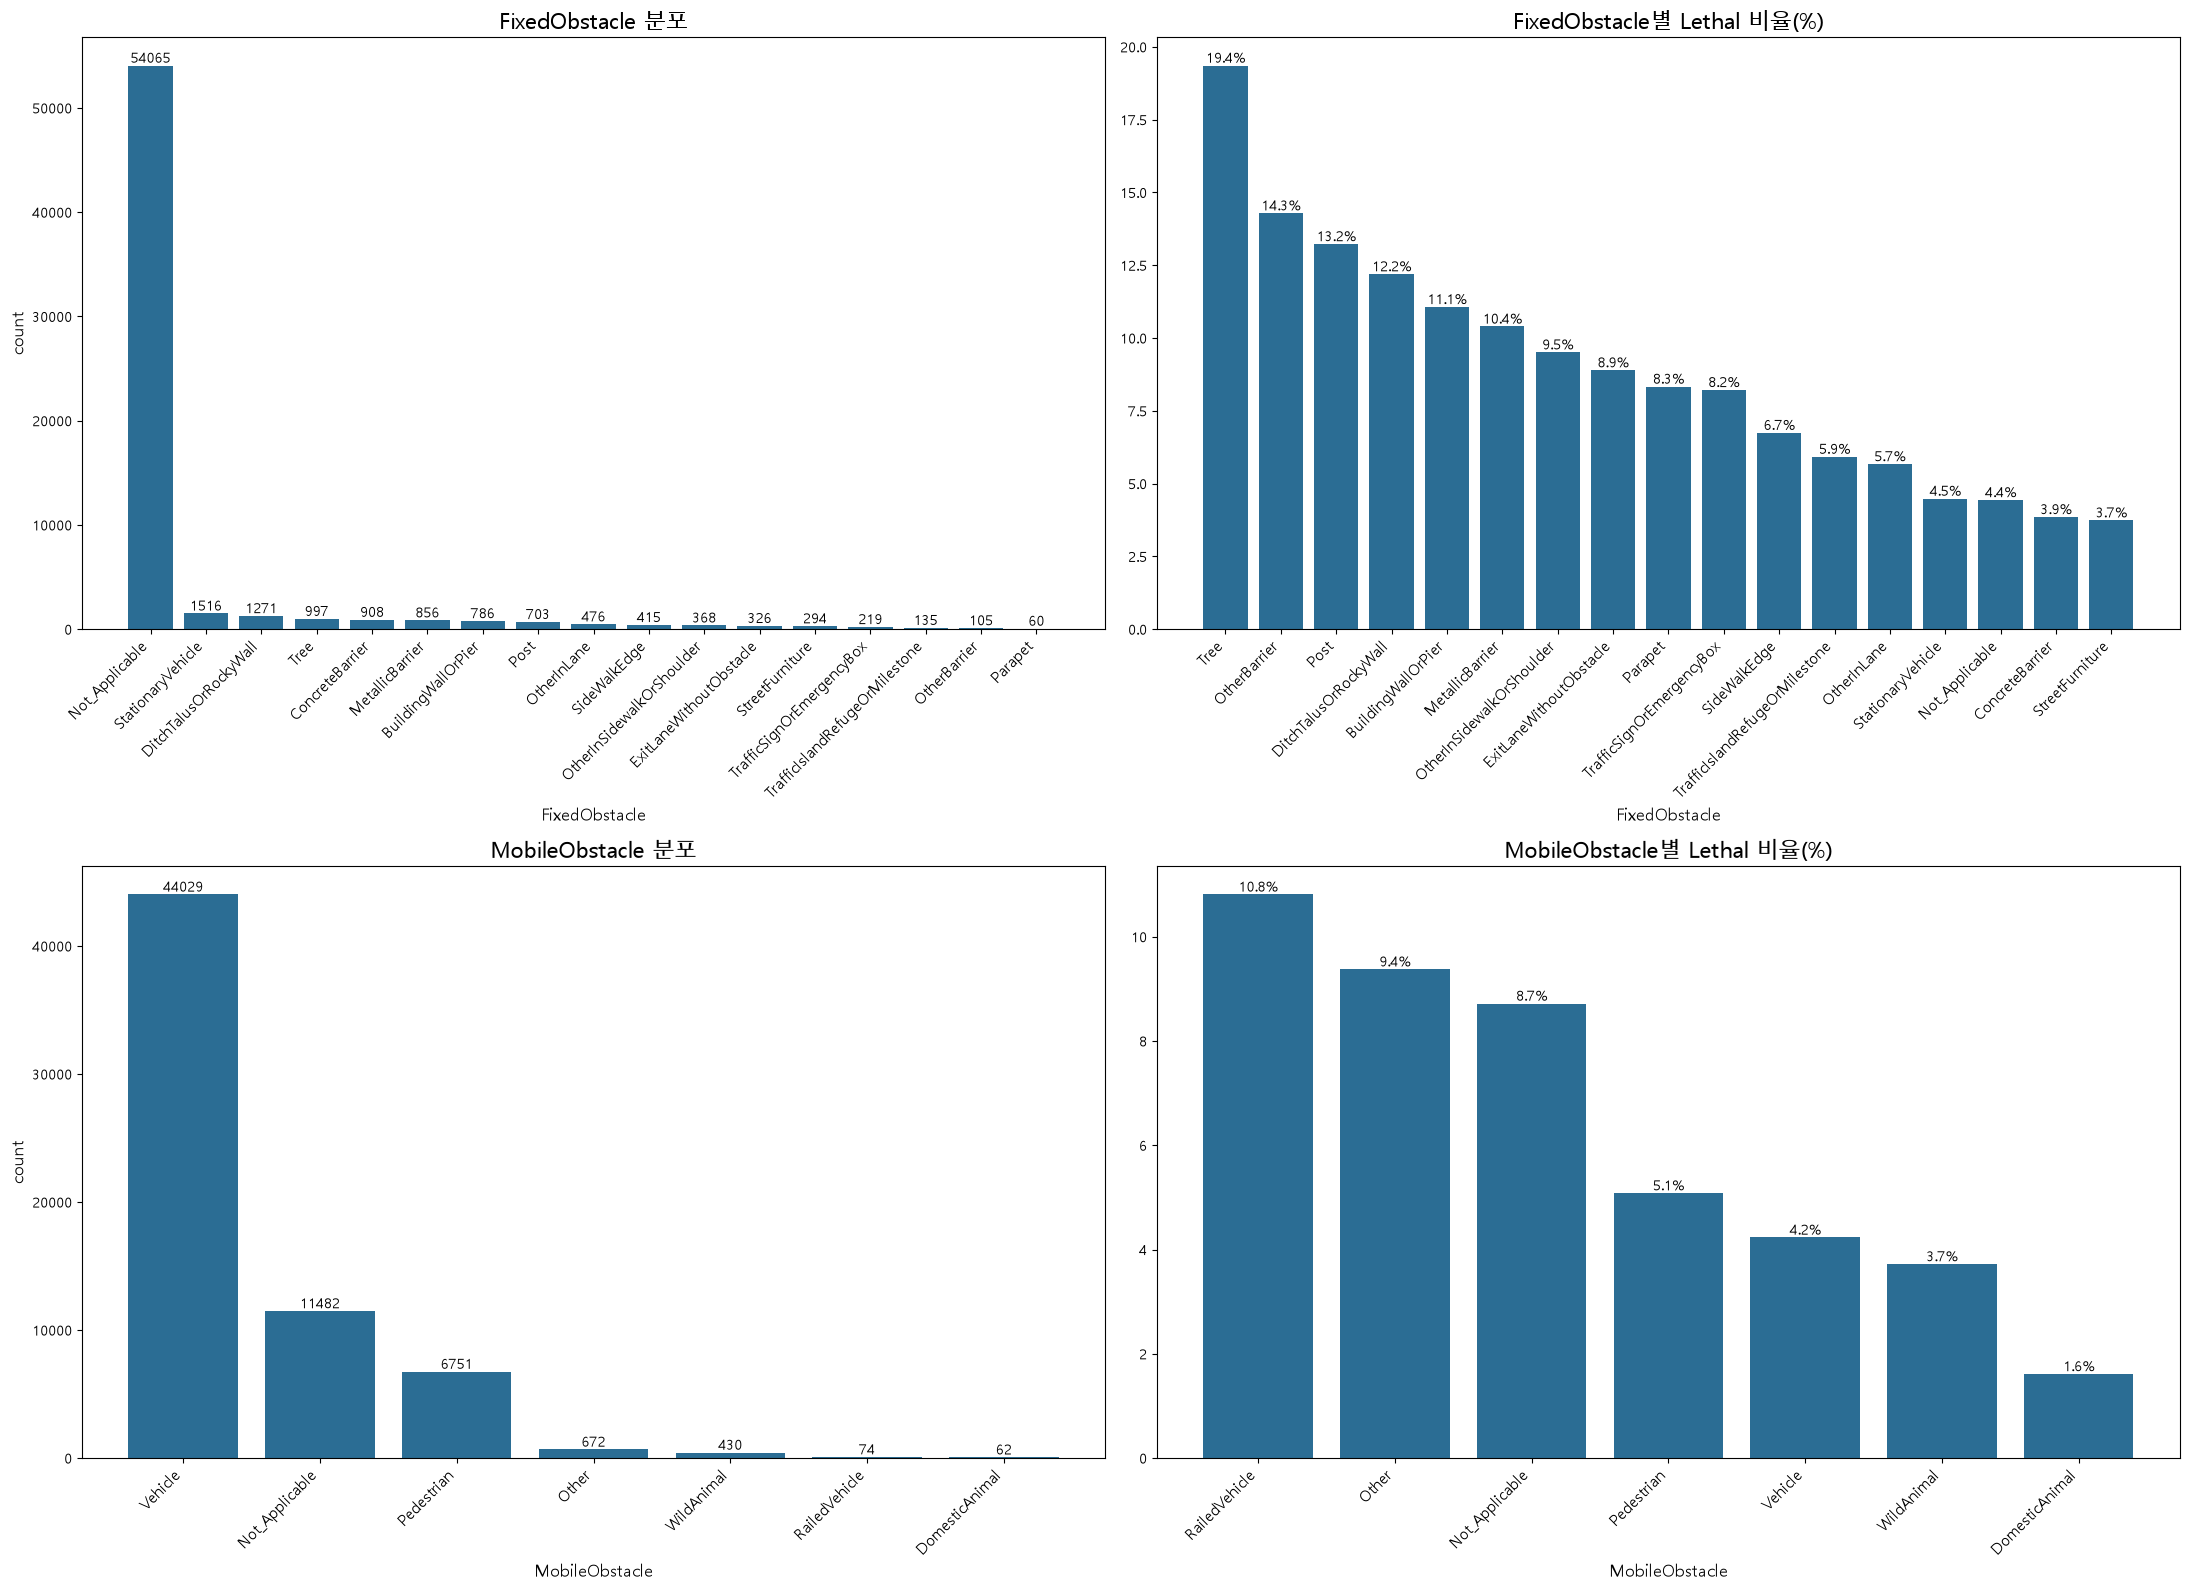

In [122]:
# 분포 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(22, 16))

cols = ['FixedObstacle', 'MobileObstacle']

for row_idx, col in enumerate(cols):
    # 분포
    counts = vehicles_train[col].value_counts()
    ax_dist = axes[row_idx, 0]
    bars = ax_dist.bar(counts.index.astype(str), counts.values, color='#2b6d94')
    ax_dist.set_title(f'{col} 분포', fontsize=16)
    ax_dist.set_xlabel(col, fontsize=12)
    ax_dist.set_ylabel('count', fontsize=12)
    ax_dist.tick_params(axis='x', rotation=45, labelsize=11)
    for label in ax_dist.get_xticklabels():
        label.set_ha('right')
    for bar, val in zip(bars, counts.values):
        ax_dist.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f'{val}', ha='center', va='bottom', fontsize=10)

    # Lethal 비율
    lethal_rate = (
        vehicles_train.groupby(col)['Gravity']
        .apply(lambda x: (x == 'Lethal').mean() * 100)
        .sort_values(ascending=False)
    )
    ax_rate = axes[row_idx, 1]
    bars2 = ax_rate.bar(lethal_rate.index.astype(str), lethal_rate.values, color='#2b6d94')
    ax_rate.set_title(f'{col}별 Lethal 비율(%)', fontsize=16)
    ax_rate.set_xlabel(col, fontsize=12)
    ax_rate.tick_params(axis='x', rotation=45, labelsize=11)
    for label in ax_rate.get_xticklabels():
        label.set_ha('right')
    for bar, val in zip(bars2, lethal_rate.values):
        ax_rate.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#### ImpactPoint 컬럼 분석 (충돌부위)

In [123]:
vehicles_train['ImpactPoint'].isna().sum()

np.int64(3427)

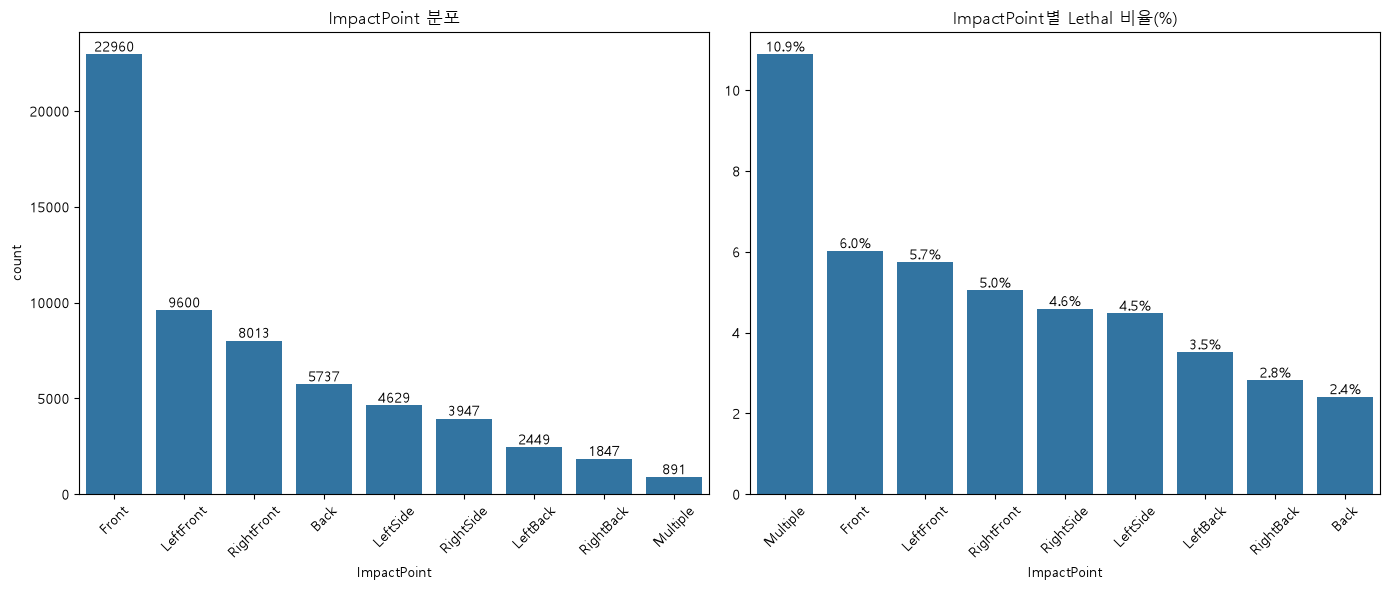

In [124]:
# 분포 시각화
plot_category_vs_gravity(vehicles_train,'ImpactPoint')

- Front 충돌이 22,960건으로 가장 많으며 앞쪽(Front/LeftFront/RightFront) 충돌이 전체의 절반 이상을 차지하고 있다.
- 치명율은 Multiple이 10.9%로 가장 높고 후면이 2.4%로 가장 낮아 정면 계열일수록 위험이 큰 경향을 보이고 있다.
- 결측치의 경우 거의 모든 사고에서 발생해야 하는 정보이지만 결측은 조사시 단순 누락으로 판단하여 'Unknown'으로 대치한다.

In [125]:
vehicles_train['ImpactPoint'] = vehicles_train['ImpactPoint'].fillna('Unknown')
vehicles_test['ImpactPoint'] = vehicles_test['ImpactPoint'].fillna('Unknown')

#### Maneuver 컬럼 분석 (주행 동작)

In [126]:
vehicles_train['Maneuver'].isna().sum()

np.int64(4992)

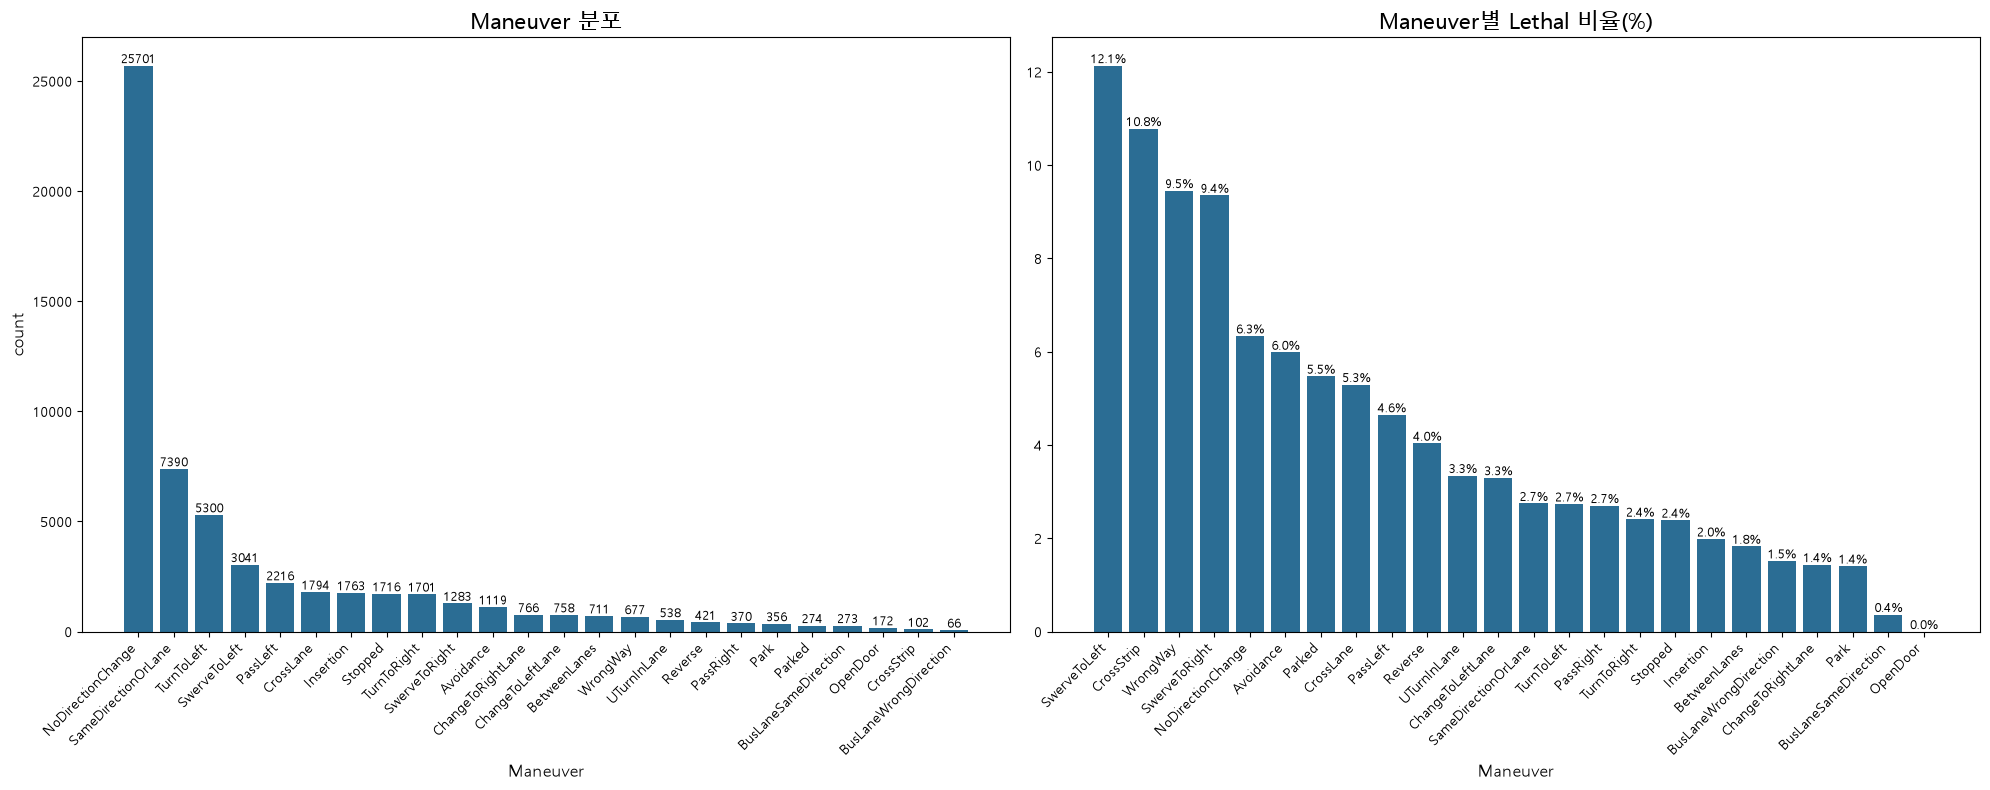

In [127]:
# 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 분포
counts = vehicles_train['Maneuver'].value_counts()
bars = axes[0].bar(counts.index.astype(str), counts.values, color='#2b6d94')
axes[0].set_title('Maneuver 분포', fontsize=16)
axes[0].set_xlabel('Maneuver', fontsize=12)
axes[0].set_ylabel('count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45, labelsize=10)
for label in axes[0].get_xticklabels():
    label.set_ha('right')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val}', ha='center', va='bottom', fontsize=9)

# Lethal 비율
lethal_rate = (
    vehicles_train.groupby('Maneuver')['Gravity']
    .apply(lambda x: (x == 'Lethal').mean() * 100)
    .sort_values(ascending=False)
)
bars2 = axes[1].bar(lethal_rate.index.astype(str), lethal_rate.values, color='#2b6d94')
axes[1].set_title('Maneuver별 Lethal 비율(%)', fontsize=16)
axes[1].set_xlabel('Maneuver', fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=10)
for label in axes[1].get_xticklabels():
    label.set_ha('right')
for bar, val in zip(bars2, lethal_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

- 원본 Maneuver는 25개 범주로 세분화되어 있으나 카테고리 간 표본 크기 편차가 매우 크다.
- 최대 범주는 25701건인 반면 최소 범주는 66건에 불과하여 희소 범주로 인한 노이즈가 우려된다.
- 의미가 유사한 동작끼리 여덟 개 그룹으로 재매핑하여 Maneuver_grouped 컬럼을 생성한다.
- 결측치는 ImpactPoint 컬럼과 같이 거의 모든 사고에서 발생해야 하는 정보이지만 조사시 단순 누락으로 판단하여 'Unknown'으로 대치한다.

In [128]:
maneuver_map = {
    'NoDirectionChange': 'Straight',
    'SameDirectionOrLane': 'Straight',
    
    'TurnToLeft': 'Turn',
    'TurnToRight': 'Turn',
    
    'SwerveToLeft': 'SwerveTurn',
    'SwerveToRight': 'SwerveTurn',
    
    'CrossLane': 'LaneChange',
    'ChangeToRightLane': 'LaneChange',
    'ChangeToLeftLane': 'LaneChange',
    'BetweenLanes': 'LaneChange',
    
    'PassLeft': 'Overtake',
    'PassRight': 'Overtake',
    
    'Stopped': 'StoppedOrParked',
    'Park': 'StoppedOrParked',
    'Parked': 'StoppedOrParked',
    'OpenDoor': 'StoppedOrParked',
    
    'WrongWay': 'HighRisk',       
    'CrossStrip': 'HighRisk',  
    
    'Avoidance': 'ModerateRisk',  
    'Reverse': 'ModerateRisk',    
    'UTurnInLane': 'ModerateRisk',
    'Insertion': 'ModerateRisk', 
    
    'BusLaneSameDirection': 'BusLane',
    'BusLaneWrongDirection': 'BusLane',
}

vehicles_train['Maneuver_grouped'] = vehicles_train['Maneuver'].map(maneuver_map)
vehicles_train['Maneuver_grouped'] = vehicles_train['Maneuver_grouped'].fillna('Unknown')

#test 적용
vehicles_test['Maneuver_grouped'] = vehicles_test['Maneuver'].map(maneuver_map)
vehicles_test['Maneuver_grouped'] = vehicles_test['Maneuver_grouped'].fillna('Unknown')

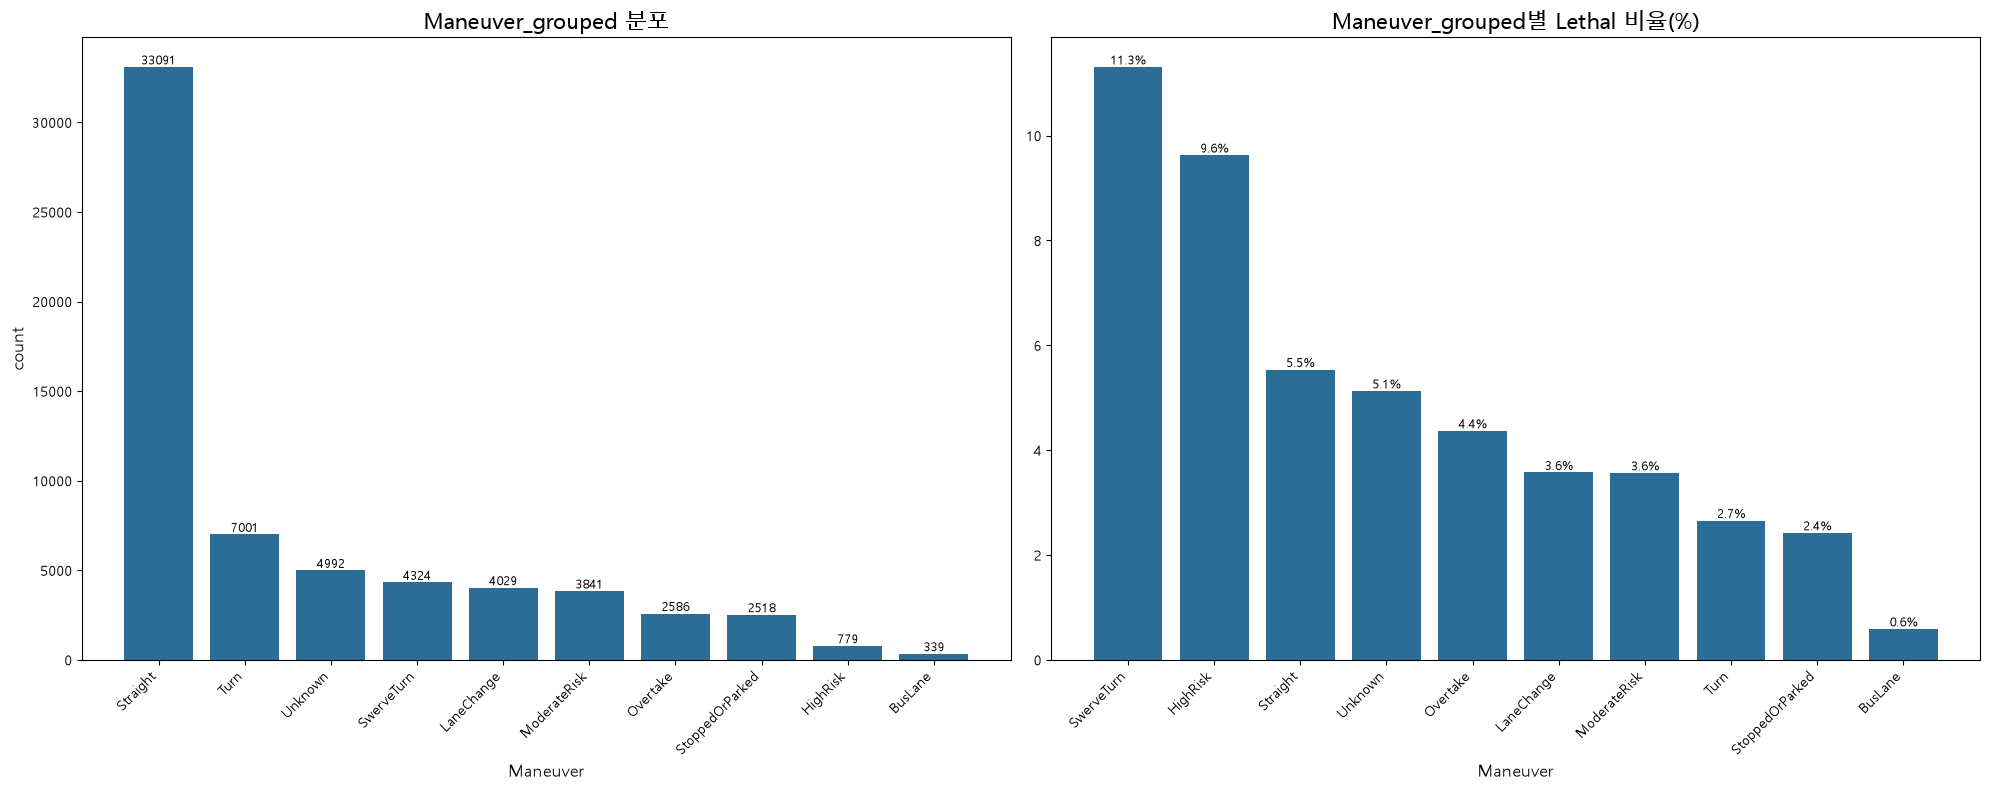

In [129]:
# 재매핑후 분포 시각화 확인
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 분포
counts = vehicles_train['Maneuver_grouped'].value_counts()
bars = axes[0].bar(counts.index.astype(str), counts.values, color='#2b6d94')
axes[0].set_title('Maneuver_grouped 분포', fontsize=16)
axes[0].set_xlabel('Maneuver', fontsize=12)
axes[0].set_ylabel('count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45, labelsize=10)
for label in axes[0].get_xticklabels():
    label.set_ha('right')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val}', ha='center', va='bottom', fontsize=9)

# Lethal 비율
lethal_rate = (
    vehicles_train.groupby('Maneuver_grouped')['Gravity']
    .apply(lambda x: (x == 'Lethal').mean() * 100)
    .sort_values(ascending=False)
)
bars2 = axes[1].bar(lethal_rate.index.astype(str), lethal_rate.values, color='#2b6d94')
axes[1].set_title('Maneuver_grouped별 Lethal 비율(%)', fontsize=16)
axes[1].set_xlabel('Maneuver', fontsize=12)
axes[1].tick_params(axis='x', rotation=45, labelsize=10)
for label in axes[1].get_xticklabels():
    label.set_ha('right')
for bar, val in zip(bars2, lethal_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

- 의미가 유사한 동작끼리 아홉 개 그룹으로 재매핑하여 Maneuver_grouped 컬럼을 생성하였다.
- SwerveToLeft와 SwerveToRight는 일반 회전과 Lethal 비율 차이가 뚜렷하여 SwerveTurn으로 별도 분리하였다.
- WrongWay와 CrossStrip은 Lethal 비율이 9퍼센트대로 높아 HighRisk로 분리하고 Avoidance와 Reverse와 UTurnInLane과 Insertion은 상대적으로 낮은 ModerateRisk로 분류하였다.

In [130]:
# Maneuver 컬럼 삭제
vehicles_train = vehicles_train.drop(columns=['Maneuver'])
vehicles_test = vehicles_test.drop(columns=['Maneuver'])

## 다중공선성 확인

In [131]:
from scipy.stats import chi2_contingency
from itertools import combinations

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    return np.sqrt(phi2 / min(r-1, k-1))

def check_multicollinearity(df, exclude_cols=None):
    exclude_cols = exclude_cols or []
    categorical_cols = [c for c in df.select_dtypes(include=['object', 'category']).columns if c not in exclude_cols]
    
    results = []
    for col1, col2 in combinations(categorical_cols, 2):
        try:
            v = cramers_v(df[col1], df[col2])
            results.append((col1, col2, v))
        except Exception:
            pass
    
    return pd.DataFrame(results, columns=['Col1', 'Col2', 'CramersV']).sort_values('CramersV', ascending=False)

In [132]:
# accidents_train
accidents_result = check_multicollinearity(accidents_train, exclude_cols=['AccidentId'])
print("=== accidents_train ===")
print(accidents_result.head(15))

=== accidents_train ===
                Col1              Col2  CramersV
6              Light   InAgglomeration  0.387268
11   InAgglomeration  IntersectionType  0.280231
13   InAgglomeration     CollisionType  0.264877
1            Gravity   InAgglomeration  0.165951
16  IntersectionType     CollisionType  0.157453
4            Gravity     CollisionType  0.127546
0            Gravity             Light  0.124789
8              Light           Weather  0.109589
7              Light  IntersectionType  0.088599
12   InAgglomeration           Weather  0.080088
9              Light     CollisionType  0.079268
2            Gravity  IntersectionType  0.073594
14   InAgglomeration         DayOfWeek  0.064411
3            Gravity           Weather  0.052445
10             Light         DayOfWeek  0.051576


##### **다중공선성 검토: accidents_train**

- Light와 InAgglomeration이 0.39로 가장 높은 연관성을 보이나 조명 상태와 시가지 여부는 자연스럽게 관련될 수 있는 정보로 판단하여 유지하였다.
- 그 외 변수 쌍은 모두 Cramér's V가 0.3 미만으로 심각한 다중공선성이 없음을 확인하여 전체 컬럼 유지한다.

In [133]:
# places_train
places_result = check_multicollinearity(places_train, exclude_cols=['AccidentId'])
print("=== places_train ===")
print(places_result.head(15))

=== places_train ===
            Col1              Col2  CramersV
10   Circulation        LaneNumber  0.449264
0       RoadType       Circulation  0.351838
37         Slope      Localization  0.276516
1       RoadType        LaneNumber  0.255653
52  Localization        SchoolNear  0.230746
34         Slope            Layout  0.201494
20    LaneNumber             Slope  0.187197
12   Circulation             Slope  0.174112
31   SpecialLane      Localization  0.160832
35         Slope  SurfaceCondition  0.154977
9       RoadType           Gravity  0.153656
16   Circulation      Localization  0.142063
24    LaneNumber      Localization  0.135998
15   Circulation    Infrastructure  0.113127
6       RoadType    Infrastructure  0.100337


##### **다중공선성 검토: places_train**

- Circulation과 LaneNumber가 0.45로 가장 높은 연관성을 보이나 도로의 통행 방식과 차선 수는 자연스럽게 관련되는 정보로 판단하여 유지한다.
- RoadType과 Circulation과 LaneNumber 간에도 중간 수준의 연관성이 있으나 도로 특성상 자연스러운 관계로 판단하여 유지한다.
- 그 외 변수 쌍은 대부분 낮은 연관성을 보여 심각한 다중공선성 없음을 확인하였다.

In [134]:
# users_train
users_result = check_multicollinearity(users_train, exclude_cols=['AccidentId', 'VehicleId'])
print("=== users_train ===")
print(users_result.head(15))

=== users_train ===
                  Col1                Col2  CramersV
65                 Age            AgeGroup  1.000000
57   PedestrianCompany        RoadUserType  0.573658
51    PedestrianAction   PedestrianCompany  0.572674
53    PedestrianAction        RoadUserType  0.567272
46  PedestrianLocation   PedestrianCompany  0.565708
48  PedestrianLocation        RoadUserType  0.560652
30        SafetyDevice    SafetyDeviceUsed  0.541780
19              Gender                 Age  0.446405
20              Gender            AgeGroup  0.445305
42    SafetyDeviceUsed        RoadUserType  0.444222
40    SafetyDeviceUsed   PedestrianCompany  0.441023
39    SafetyDeviceUsed    PedestrianAction  0.436671
38    SafetyDeviceUsed  PedestrianLocation  0.431542
45  PedestrianLocation    PedestrianAction  0.425458
2             Category        SafetyDevice  0.423529


##### **다중공선성 검토: users_train**

- Age와 AgeGroup은 Cramér's V가 1.0으로 완전 중복 관계이며 AgeGroup이 Age에서 파생된 컬럼이므로 원본 Age는 모델링에서 제외하고 AgeGroup만 사용한다.
- SafetyDevice와 SafetyDeviceUsed는 0.54로 강하게 연관되어 있어 필요에 따라 하나만 선택하거나 결합한 파생 변수 사용을 고려할 예정이다.
- PedestrianCompany와 RoadUserType은 0.57로 강한 연관성을 보이나 RoadUserType을 만드는 과정에서 PedestrianCompany 정보를 일부 활용했기 때문에 나타나는 자연스러운 결과로 판단하였다.
- Gender와 Age와 AgeGroup과 SafetyDevice 간에는 중간 수준의 연관성이 있으나 각각 고유한 정보를 담고 있다고 판단하여 유지한다.
- 그 외 변수 쌍은 대부분 낮은 연관성을 보여 심각한 다중공선성 없음을 확인하였다.

In [135]:
# vehicles_train
vehicles_result = check_multicollinearity(vehicles_train, exclude_cols=['AccidentId'])
print("=== vehicles_train ===")
print(vehicles_result.head(15))

=== vehicles_train ===
              Col1              Col2  CramersV
5    FixedObstacle    MobileObstacle  0.254612
13     ImpactPoint  Maneuver_grouped  0.155288
9   MobileObstacle       ImpactPoint  0.128533
7    FixedObstacle           Gravity  0.115359
11  MobileObstacle  Maneuver_grouped  0.094421
14         Gravity  Maneuver_grouped  0.093824
10  MobileObstacle           Gravity  0.079867
4        Direction  Maneuver_grouped  0.076431
8    FixedObstacle  Maneuver_grouped  0.076344
6    FixedObstacle       ImpactPoint  0.072378
12     ImpactPoint           Gravity  0.060528
2        Direction       ImpactPoint  0.052265
0        Direction     FixedObstacle  0.049724
1        Direction    MobileObstacle  0.046895
3        Direction           Gravity  0.039084


- places_train, users_train, vehicles_train에 있는 ['Gravity'] 컬럼 삭제 한다.

In [136]:
places_train = places_train.drop(columns=['Gravity'])
users_train = users_train.drop(columns=['Gravity'])
vehicles_train = vehicles_train.drop(columns=['Gravity'])

##### **다중공선성 검토: vehicles_train**

- FixedObstacle과 MobileObstacle은 0.25로 낮은 수준의 연관성을 보여 별도 조치 없이 유지하였다.
- 그 외 변수 쌍은 대부분 0.15 미만으로 심각한 다중공선성 없음을 확인하였다.

### 데이터셋 정합성 확인

In [137]:
# train/test 데이터셋 쌍 정의
dataset_pairs = {
    'accidents': (accidents_train, accidents_test),
    'places': (places_train, places_test),
    'users': (users_train, users_test),
    'vehicles': (vehicles_train, vehicles_test),
}

for name, (train_df, test_df) in dataset_pairs.items():
    train_cols = set(train_df.columns)
    test_cols = set(test_df.columns)

    only_in_train = train_cols - test_cols
    only_in_test = test_cols - train_cols

    print(f"=== {name} ===")
    print(f"train 컬럼 수: {len(train_cols)}, test 컬럼 수: {len(test_cols)}")

    if not only_in_train and not only_in_test:
        print("컬럼 동일 (일치)")
    else:
        if only_in_train:
            print(f"train에만 있는 컬럼: {sorted(only_in_train)}")
        if only_in_test:
            print(f"test에만 있는 컬럼: {sorted(only_in_test)}")
    print()

=== accidents ===
train 컬럼 수: 12, test 컬럼 수: 12
컬럼 동일 (일치)

=== places ===
train 컬럼 수: 11, test 컬럼 수: 11
컬럼 동일 (일치)

=== users ===
train 컬럼 수: 18, test 컬럼 수: 18
컬럼 동일 (일치)

=== vehicles ===
train 컬럼 수: 6, test 컬럼 수: 6
컬럼 동일 (일치)



# 전처리 데이터 저장하기

In [138]:
import os

# 저장 경로 생성
save_dir = './data/Cleaning'
os.makedirs(save_dir, exist_ok=True)

accidents_train.to_csv('./data/Cleaning/accidents_train.csv', index=False)
accidents_test.to_csv('./data/Cleaning/accidents_test.csv', index=False)

places_train.to_csv('./data/Cleaning/places_train.csv', index=False)
places_test.to_csv('./data/Cleaning/places_test.csv', index=False)

users_train.to_csv('./data/Cleaning/users_train.csv', index=False)
users_test.to_csv('./data/Cleaning/users_test.csv', index=False)

vehicles_train.to_csv('./data/Cleaning/vehicles_train.csv', index=False)
vehicles_test.to_csv('./data/Cleaning/vehicles_test.csv', index=False)

print("전체 저장 완료")

전체 저장 완료
